# Предсказание статуса деятельности стартапа

Соревнование представляет собой увлекательный и практически важный опыт, ориентированный на студентов курса Data Science. Участникам предстоит работать с псевдо-реальными (реальные данные в которые добавлена синтетическая составляющая) данными о стартапах, функционировавших в период с 1970 по 2018 годы, и предсказать, какие из них закроются. Соревнование проводится на популярной платформе Kaggle, что позволяет участникам не только применять на практике свои знания в области анализа данных и машинного обучения, но и освоить работу с этой платформой.

## Описание проекта

**Заказчик**

Соревнование Kaggle / инвестор, который сделать первичный отбор

**Входные данные**

Псевдо-реальные данные о стартапах, функционировавших в период с 1970 по 2018 годы, включающие годы работы, финансирование, область и т.д., в том числе и статус деятельности стартапа.

**Задача**

Необходимо разработать модель машинного обучения для предсказания статуса деятельности стартапа (работает / закрыт).
Провести полноценный разведочный анализ и сформировать рекомендации для потенциальных инвесторов / будущих создателей стартапов.

**Цель**

Предсказание продолжительности деятельности стартапа и определение параметров влияющих на рабочий статус, что может помочь потенциальному инвестору или будущим создателям стартапов.

**Описание входных данных**

**`kaggle_startups_train_01.csv`** - информация о (53 000) стартапах, которые будут использоваться в качестве обучающих данных
**`kaggle_startups_test_01.csv`** - информация о (13 000) стартапах, которые будут использоваться в качестве тестовых данных

- `name` - название стартапа
- `category_list` - список категорий, к которым относится стартап
- `funding_total_usd` - общая сумма финансирования в USD
- `status` - статус стартапа (закрыт или действующий)
- `country_code` - код страны
- `state_code` - код штата
- `region` - регион
- `city` - город
- `funding_rounds` - количество раундов финансирования
- `founded_at` - дата основания
- `first_funding_at` - дата первого раунда финансирования
- `last_funding_at` - дата последнего раунда финансирования
- `closed_at` - дата закрытия стартапа (если применимо)
- `lifetime` - время существования стартапа в днях

In [1]:
!pip install numba==0.57.1 -q
!pip install phik -q
!pip install catboost -q
!pip install lightgbm -q
!pip install shap==0.44.0 -q
!pip install optuna-integration -q
!pip install scikit-learn --upgrade -q
!pip install pingouin -q
!pip install --upgrade seaborn -q
!pip install matplotlib==3.9.2 -q

In [2]:
# данные
import pandas as pd
import numpy as np
import re

# графики
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# статистика
from scipy.stats import chi2_contingency, ttest_ind
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# машинное обучение
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OrdinalEncoder,
    StandardScaler,
    RobustScaler,
    LabelEncoder
)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV

from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.calibration import (
    CalibratedClassifierCV,
    calibration_curve,
    CalibrationDisplay
)

# Метрики
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    precision_recall_curve,
    make_scorer,
    f1_score
)


import pingouin as pg
import phik
import shap
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from optuna import create_study, distributions, Trial
from optuna.samplers import TPESampler

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

## Разведочный анализ

In [3]:
# зададим функцию для импорта данных и вывода первичной информации по ним
# data_name - имя датафрейма для создания, filepath - путь к файлу в формате string
def import_data_info(dataset_path, sep=',', decimal='.', date_cols=[]):
    try:
        data_name = pd.read_csv(dataset_path, sep=sep, decimal=decimal, parse_dates=date_cols)
    except:
        return 'Не получилось открыть файл, проверьте имя файла и путь'

    data_name.info()
    display(data_name.head())
    print(f'\nПолных явных дубликатов - {data_name.duplicated().sum()}')

    print('\nУникальных значений и пропусков в признаках:')
    df = {'values' : ['Unique, count',
                      'Unique, %',
                      'Missing, count',
                      'Missing, %'
                     ]
         }
    for col in data_name:
        df[col]=[
                 data_name[col].nunique(),
                 round(100 * data_name[col].nunique() / data_name.shape[0], 1),
                 data_name[col].isnull().sum(),
                 round(100 * data_name[col].isnull().sum() / data_name.shape[0], 1)
                ]
    display(pd.DataFrame(df).set_index('values'))

    return data_name

In [5]:
data_test = import_data_info('kaggle_startups_test_28062024.csv',
                             date_cols=['first_funding_at',
                                          'last_funding_at'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13125 entries, 0 to 13124
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   name               13125 non-null  object        
 1   category_list      12534 non-null  object        
 2   funding_total_usd  10547 non-null  float64       
 3   country_code       11743 non-null  object        
 4   state_code         11430 non-null  object        
 5   region             11536 non-null  object        
 6   city               11538 non-null  object        
 7   funding_rounds     13125 non-null  int64         
 8   first_funding_at   13125 non-null  datetime64[ns]
 9   last_funding_at    13125 non-null  datetime64[ns]
 10  lifetime           13125 non-null  int64         
dtypes: datetime64[ns](2), float64(1), int64(2), object(6)
memory usage: 1.1+ MB


,name,category_list,funding_total_usd,country_code,state_code,region,city,funding_rounds,first_funding_at,last_funding_at,lifetime
0,Crystalsol,Clean Technology,2819200.0,NIC,17,NaN,NaN,1,2009-07-01,2009-07-01,3501
1,JBI Fish & Wings,Hospitality,NaN,USA,TN,TN - Other,Humboldt,1,2010-07-28,2010-07-28,2717
2,COINPLUS,Finance,428257.0,LUX,3,Esch-sur-alzette,Esch-sur-alzette,2,2014-05-15,2014-09-18,1295
3,Imagine Communications,Software|Video|Video Streaming,34700000.0,USA,CA,San Diego,San Diego,4,2005-01-01,2010-04-20,4748
4,DNA13,Software,4530000.0,CAN,ON,Ottawa,Ottawa,1,2007-05-08,2007-05-08,6209



Полных явных дубликатов - 0

Уникальных значений и пропусков в признаках:


,name,category_list,funding_total_usd,country_code,state_code,region,city,funding_rounds,first_funding_at,last_funding_at,lifetime
values,,,,,,,,,,,
"Unique, count",13125.0,6206.0,4549.0,96.0,235.0,688.0,2117.0,15.0,3299.0,3021.0,3456.0
"Unique, %",100.0,47.3,34.7,0.7,1.8,5.2,16.1,0.1,25.1,23.0,26.3
"Missing, count",0.0,591.0,2578.0,1382.0,1695.0,1589.0,1587.0,0.0,0.0,0.0,0.0
"Missing, %",0.0,4.5,19.6,10.5,12.9,12.1,12.1,0.0,0.0,0.0,0.0


### Вывод

Данные импортировались корректно, формат данных везде корректный, формат дат сохранили при импорте.

- **Тренировочные данные - `data_train`**
    - 52516 записей
    - явных полных дубликатов нет
    - пропуски
        - `name` - 1 название стартапа отсутствует
        - `category_list` - 2465 (4.7 %)
        - `funding_total_usd` - 10069 (19.2 %)
        - `country_code` - 5502 (10.5 %)
        - `state_code` - 6763 (12.9 %)
        - `region` - 6359 (12.1 %)
        - `city` - 6359 (12.1 %)
        - `closed_at` - 47599 (90.6 %)
    - уникальные значения
        - `status` - 2 категории (operating/closed)
        - `funding_rounds` - 19 категорий, от 1 до 19 - ранжированный (количество раундов)
        - `category_list` - 22105 (42.1 %), очень много, явно есть проблемы


- **Тестовые данные - `data_test`**
    - 13125 записей
    - явных полных дубликатов нет
    - пропуски
        - `category_list` - 591 (4.5 %)
        - `funding_total_usd` - 2578 (19.6 %)
        - `country_code` - 1382 (10.5 %)
        - `state_code` - 1695 (12.9 %)
        - `region` - 1589 (12.1 %)
        - `city` - 1587 (12.1 %)
    - уникальные значения
        - `funding_rounds` - 15 категорий, от 1 до 15 - ранжированный (количество раундов)
        - `category_list` - 6206 (47.3 %), очень много, явно есть проблемы


- **Общие наблюдения**
    - В тестовой выборке присутствует признак `lifetime`, тогда как в тренировочных данных он отсутствует, но вместо него есть признаки `founded_at` и `closed_at`, через которые его можно вычислить
    - В тестовой выборке отсутствует признак `status` - его нам необходимо спрогнозировать
    - Много пропусков в тренировочной выборке в признаке `closed_at` - 90.2 %, возможно есть корреляция со статусом, например, эти стартапы еще работают, посмотрим позднее
    - В признаке `category_list` есть как единичные категории, так и мультикатегории, указанные через `|`, возможно есть и другие разделители, будем разделять
    - Пропуски в обоих выборках распределены практически одинаково, поэтому для одинаковых признаков обработку пропусков будем проводить в пайплайне

## Предобработка данных

Посмотрим на пропуски и неявные дубликаты

### `name`

Был один пропуск, посмотрим на него

In [6]:
data_train.query('name.isna()')

,name,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at,closed_at
3291,NaN,Startups,25000.0,closed,USA,OR,"Portland, Oregon",Portland,1,2011-10-01,2012-03-01,2012-03-01,2013-06-03


Просуществовал около 2 лет, данные выглядят адекватно, присвоим ему имя `NoNameStartup`

In [7]:
data_train.loc[data_train.query('name.isna()').index[0], 'name'] = 'NoNameStartup'
data_train.query('name=="NoNameStartup"')

,name,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at,closed_at
3291,NoNameStartup,Startups,25000.0,closed,USA,OR,"Portland, Oregon",Portland,1,2011-10-01,2012-03-01,2012-03-01,2013-06-03


### `closed_at`

90.2 % (47599) пропусков, посмотрим на связь с `status`

In [8]:
data_train.query('closed_at.isna()')['status'].value_counts()

status
operating    47599
Name: count, dtype: int64

Как раз столько же записей со статусом `operating`. Пропуски заменим на дату выгрузки данных - `2018-01-01`. Посчитаем с помощью него `lifetime` как в тестовой выборке и добавим признак в тренировочную выборку, а признаки с датами создания и закрытия выбросим, так как в тестовой выборке их нет

In [9]:
data_train.fillna({'closed_at': pd.to_datetime('2018-01-01')}, inplace=True)
data_train.query('status=="operating"')['closed_at'].unique()

<DatetimeArray>
['2018-01-01 00:00:00']
Length: 1, dtype: datetime64[ns]

In [10]:
data_train['lifetime'] = (
    (data_train['closed_at'] - data_train['founded_at']).dt.days.astype('int'))
data_train.drop(['closed_at'], axis=1, inplace=True)
data_train.head()

,name,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at,lifetime
0,Lunchgate,Online Reservations|Restaurants,828626.0,operating,CHE,25,Zurich,Zürich,2,2009-10-17,2011-05-01,2014-12-01,2998
1,EarLens,Manufacturing|Medical|Medical Devices,42935019.0,operating,USA,CA,SF Bay Area,Redwood City,4,2005-01-01,2010-05-04,2014-02-25,4748
2,Reviva Pharmaceuticals,Biotechnology,35456381.0,operating,USA,CA,SF Bay Area,San Jose,3,2006-01-01,2012-08-20,2014-07-02,4383
3,Sancilio and Company,Health Care,22250000.0,operating,NaN,NaN,NaN,NaN,3,2004-01-01,2011-09-01,2014-07-18,5114
4,WireTough Cylinders,Manufacturing,NaN,operating,USA,VA,VA - Other,Bristol,1,2010-05-12,2012-02-01,2012-02-01,2791


### Географические признаки `country_code`, `state_code`, `region` и `city`

В `state_code`, `region` и `city` примерно 12.3 % пропусков, а в `country_code` немного меньше - 10.5 % (5502). Посмотрим насколько пропуски пересекаются, но логично предположить, что 10.5 % пропусков по всем четырем признакам, и около 2 % содержат в записях страну, но содержат более точныев географические признаки

In [11]:
data_train.query('country_code.isna()' \
                 'and region.isna() and state_code.isna()')['name'].count()

5502

In [12]:
data_train.query('not country_code.isna()' \
                 'and region.isna() and status=="closed"')['country_code'].value_counts().head(10)

country_code
RUS    22
GBR    14
ISR    10
USA     7
SWE     4
FRA     4
CHN     2
PER     2
ESP     2
IND     2
Name: count, dtype: int64

Так и есть, 10.5 % географических пропусков мы точно не сможем даже приблизительно заполнить, только если не парсить crunchbase или bloomberg. Поэтому в пайплайне заполним их `Unknown`. Остается 2.5 % пропусков с регионах и городах, где указан `country_code`, что в теории можно было бы заполнить столицей стран или самым частым значением для каждой страны. Вопрос, стоят ли 2.5 % пропусков в этих признаках трудозатрат, при том, что регион или город вряд ли будет значимо влиять на предсказание (возможно кроме США).

In [13]:
data_train.query('not country_code.isna()' \
                 'and state_code.isna()')['country_code'].value_counts().head(10)

country_code
SGP    356
HKG    162
CHN    115
ISR     84
GBR     83
ZAF     71
USA     35
RUS     35
VNM     29
JPN     25
Name: count, dtype: int64

В пропуски в `state_code` кроме полных географических пропусков добавляются пропуски у моногородов - Сингапур и Гонкног (518 пропусков), как раз составляет небольшую разницу для пропусков у городов и штатов

Кроме того, возможно в городах и регионах есть неявные дубликаты, чей поиск и правка может занять еще большее время (`Rome` и `Roma`, `Milan` и `Milano`)

In [14]:
data_train.query('country_code=="ITA"').head(10)

,name,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at,lifetime
207,PerMicro,Finance,5.421200e+06,operating,ITA,7,Rome,Rome,1,2009-03-30,2011-02-07,2011-02-07,3199
209,GlassUp,Augmented Reality|Consumer Electronics|Hardwar...,1.277000e+05,operating,ITA,5,Modena,Modena,1,2012-10-09,2013-08-31,2013-08-31,1910
226,RiparAutOnline,Automotive|Bicycles|Price Comparison,6.604700e+04,operating,ITA,12,Turin,Torino,1,2012-06-26,2013-07-25,2013-07-25,2015
329,Equinvest,Banking|Financial Services|Venture Capital,1.701394e+05,operating,ITA,7,Rome,Roma,1,2014-06-11,2015-10-19,2015-10-19,1300
395,Winmedical,Health Care,5.142788e+06,operating,ITA,16,Pisa,Pisa,5,2009-01-01,2011-03-01,2015-10-05,3287
400,Xmetrics,Audio|Real Time|Sports|Swimming|Technology,1.000000e+06,operating,ITA,NaN,NaN,NaN,1,2014-06-10,2014-10-16,2014-10-16,1301
666,RingTu,Cloud Computing|Communications Hardware,5.777970e+05,operating,ITA,7,Rome,Latina,3,2013-01-01,2012-12-01,2013-11-01,1826
693,Zuffle,Application Platforms|Entertainment|Games|Grap...,1.323510e+05,operating,ITA,17,ITA - Other,Prato,1,2012-04-21,2013-07-26,2013-07-26,2081
924,Formabilio,Design|E-Commerce|Environmental Innovation|Sta...,NaN,closed,ITA,20,ITA - Other,Cison Di Valmarino,1,2012-09-26,2014-05-07,2014-05-07,1150
989,WIB,E-Commerce,9.649500e+05,operating,ITA,15,Palermo,Palermo,1,2013-01-01,2014-03-28,2014-03-28,1826


### `category_list`

Посмотрим на специальные символы, который встречаются в признаке. Разделителем может быть не только `|`

In [15]:
set(data_train['category_list'].dropna().sum())

{' ',
 '&',
 '+',
 '-',
 '.',
 '/',
 '0',
 '1',
 '2',
 '3',
 '7',
 'A',
 'B',
 'C',
 'D',
 'E',
 'F',
 'G',
 'H',
 'I',
 'J',
 'K',
 'L',
 'M',
 'N',
 'O',
 'P',
 'Q',
 'R',
 'S',
 'T',
 'U',
 'V',
 'W',
 'Y',
 'Z',
 'a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z',
 '|'}

Есть ещё похожие на разделитель категорий `&`, `+` и `/`. Посмотрим на них

In [16]:
df_ = data_train['category_list'].dropna().str.split('|').explode().value_counts().reset_index()
display(df_[df_['category_list'].str.contains('\+')])
display(df_[df_['category_list'].str.contains('&')])
display(df_[df_['category_list'].str.contains('/')])

,category_list,count
19,Hardware + Software,1171
387,Social + Mobile + Local,43


,category_list,count
151,Travel & Tourism,145
236,Home & Garden,90
314,Oil & Gas,58
549,Mobile Emergency&Health,20
630,Q&A,13


,category_list,count
686,DOD/Military,9


- `+` - `Hardware + Software` и `Social + Mobile + Local`
- `&` - `Travel & Tourism`, `Home & Garden`, `Oil & Gas`, `Mobile Emergency&Health` и `Q&A`
- `/` - `DOD/Military`

Больше всего в первой выборке - около 1200. Все категории в целом выглядят как самостоятельные категории.

Выше в выборке можно отметить, что присутствует до 5 категорий точно через разделитель в признаке, может и больше, но пяти нам хватит.

In [17]:
# функция разделения признака category_list по разделителю |
def cat_separation(data):
    cat_listed = data['category_list'].str.split('|')
    for i in range(5):
        data['category_'+str(i+1)] = cat_listed.str[i]
    cat_listed = []

In [18]:
cat_separation(data_train)
data_train.head(3)

,name,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at,lifetime,category_1,category_2,category_3,category_4,category_5
0,Lunchgate,Online Reservations|Restaurants,828626.0,operating,CHE,25,Zurich,Zürich,2,2009-10-17,2011-05-01,2014-12-01,2998,Online Reservations,Restaurants,NaN,NaN,NaN
1,EarLens,Manufacturing|Medical|Medical Devices,42935019.0,operating,USA,CA,SF Bay Area,Redwood City,4,2005-01-01,2010-05-04,2014-02-25,4748,Manufacturing,Medical,Medical Devices,NaN,NaN
2,Reviva Pharmaceuticals,Biotechnology,35456381.0,operating,USA,CA,SF Bay Area,San Jose,3,2006-01-01,2012-08-20,2014-07-02,4383,Biotechnology,NaN,NaN,NaN,NaN


In [19]:
cat_separation(data_test)
data_test.head(3)

,name,category_list,funding_total_usd,country_code,state_code,region,city,funding_rounds,first_funding_at,last_funding_at,lifetime,category_1,category_2,category_3,category_4,category_5
0,Crystalsol,Clean Technology,2819200.0,NIC,17,NaN,NaN,1,2009-07-01,2009-07-01,3501,Clean Technology,NaN,NaN,NaN,NaN
1,JBI Fish & Wings,Hospitality,NaN,USA,TN,TN - Other,Humboldt,1,2010-07-28,2010-07-28,2717,Hospitality,NaN,NaN,NaN,NaN
2,COINPLUS,Finance,428257.0,LUX,3,Esch-sur-alzette,Esch-sur-alzette,2,2014-05-15,2014-09-18,1295,Finance,NaN,NaN,NaN,NaN


### `funding_total_usd`

В 19.2 % случаях есть пропуски, возможно они связаны с нераскрытием информации или отсутствием инвестиций через раунды, т.е. стартапы развивались без привлечения внешних инвестиций

In [20]:
data_train.query('funding_total_usd.isna()')['funding_rounds'].value_counts()

funding_rounds
1     9189
2      706
3      121
4       36
5        8
6        3
10       2
7        2
8        1
9        1
Name: count, dtype: int64

Стартапы с более чем одним раундом инвестиций явно привлекали инвестиции, но информация по ним не раскрывалась. Стартапы с одним раундом инвестиций могли не привлекать инвестиций и работать только с помощью собственных вложений, но на аггрегаторе информация по раундам будет стоять все равно 1.

Заполним пропуски скорее всего 0, но посмотрим в исследовательском анализе, возможно будет что-то более хитрое

### Вывод

- `name` - заполнили 1 пропуск `NoNameStartup`
- `closed_at` - 45000 пропусков заменили на дату выгрузки данных - `2018-01-01`
- `lifetime` - добавили признак как в тестовой выбокре равный разнице `closed_at` и `founded_at`
- `country_code`, `state_code`, `region` и `city` около 12.5% пропусков заполним позже в пайплайне `Unknown`
- `category_list` - разделили по `|` на пять категорий и создали для них соответствующие признаки `category_i`. Пропуски заполним в пайплайне позже `Unknown`
- `funding_total_usd` - пропуски скорее всего заполним 0

## Исследовательский анализ

In [21]:
sns.set(font_scale=1.2)
sns.set_style('whitegrid', {'axes.edgecolor': 'black'})

# Определим функцию для графического и описательного анализа столбцов
def describe_column(data, hue=None, alpha=1, ax=None):

    # Условие на тип диаграммы не категориальной без сравнения:

    if (data.dtype != object) & (hue is None):

        fig = plt.figure(figsize=(20,6))
        # проверка на непрерывность
        if data.nunique() > 25:

            # Настройки сетки графика
            gs = gridspec.GridSpec(2, 2, height_ratios=[5, 1])
            gs.update(hspace=0)
            ax_hist = plt.subplot(gs[0, 0])
            ax_box = plt.subplot(gs[1, 0])
            ax_qq = plt.subplot(gs[:, 1])

            # Boxplot и гистограмма
            sns.boxplot(x=data, ax=ax_box)
            sns.histplot(x=data,
                         bins='sturges',
                         alpha=alpha,
                         edgecolor='black',
                         ax=ax_hist,
                         stat='probability')
            plt.subplots_adjust(hspace=0)

        # дискретный
        else:
            # Настройки сетки графика
            gs = gridspec.GridSpec(1, 2)
            ax_hist = plt.subplot(gs[0])
            ax_qq = plt.subplot(gs[1])

            sns.countplot(x=data,
                alpha=alpha,
                edgecolor='black',
                #stat = 'probability',
                ax=ax_hist)

        ax_hist.set_ylabel('Частота', size=14)
        ax_hist.set_title(f'Распределение признака {data.name}', size=14)

        # QQ-plot
        pg.qqplot(data, ax=ax_qq, square=False)
        ax_qq.set_title(f'Нормальный график Q-Q признака {data.name}', size=14)
        ax_qq.set_xlabel('Нормальные квантили', size=14)
        ax_qq.set_ylabel('Признаковые квантили', size=14)

        plt.show()

        # Описательная статистика
        display(pd.DataFrame(data.describe()).T)

    # Условие на тип диаграммы не категориальной со сравнением по признаку:
    elif hue is not None:
        fig = plt.figure(figsize=(12,6))

        if data.nunique() < 12:
            discr = True
            shr = 0.8
            multi = 'dodge'
        else:
            discr = None
            shr = 1
            multi = 'layer'

        sns.histplot(x=data,
                     alpha=alpha,
                     hue=hue,
                     edgecolor='black',
                     common_norm=False,
                     stat='probability',
                     bins='sturges',
                     discrete=discr,
                     shrink=shr,
                     multiple=multi)
        plt.title(f'Распределение признака {data.name} в зависимости от {hue.name}',
                  size=14)
        plt.show()

    # Условие на категориальный тип диаграммы
    else:
        if ax is not None:
            data.value_counts().plot(kind='pie',
                                     autopct=make_autopct(data.value_counts()),
                                     fontsize=12, ax=ax)
        else:
            data.value_counts().plot(kind='pie',
                                     autopct=make_autopct(data.value_counts()),
                                     fontsize=12, figsize=(6, 6))
        plt.title(f'Распределение признака {data.name}', fontsize=12)
        plt.ylabel('')

# создадим дополнтильную функцию для вывода количества элементов в блоке для графика pie
# возвращает подпись элемента в % и число
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return '{p:.2f}%\n({v:d})'.format(p=pct,v=val)
    return my_autopct

### `status`

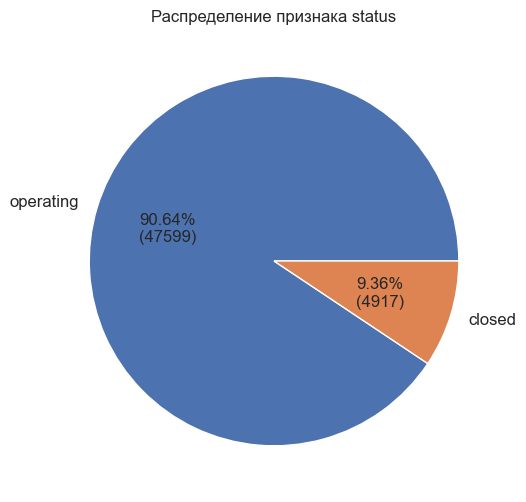

In [22]:
describe_column(data_train['status'])

Сильный дисбаланс между классами - 9 к 1. Если будем использовать логрег - придется сэмплировать

### `funding_total_usd`

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


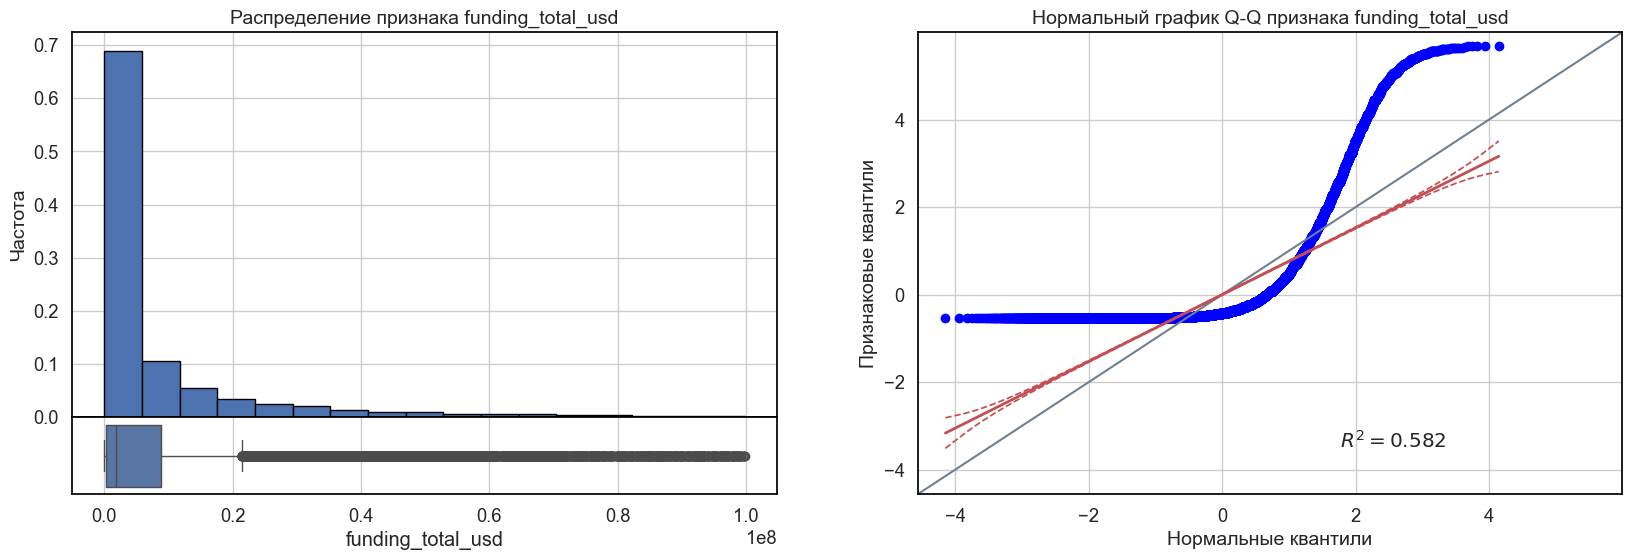

,count,mean,std,min,25%,50%,75%,max
funding_total_usd,41137.0,8.642092e+06,1.603147e+07,1.0,300000.0,1818301.0,8770048.0,99800000.0


In [23]:
describe_column(data_train[data_train['funding_total_usd']<100000000]['funding_total_usd'])

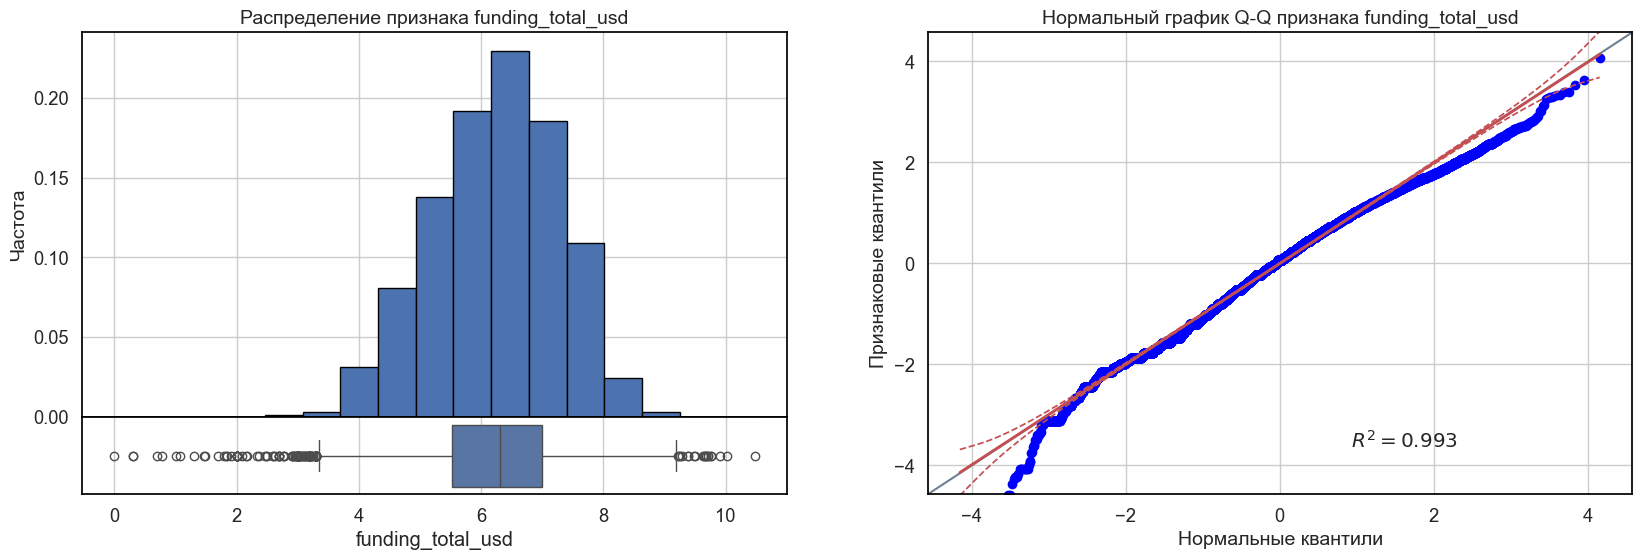

,count,mean,std,min,25%,50%,75%,max
funding_total_usd,42447.0,6.239643,1.040337,0.0,5.526375,6.30103,7.0,10.478271


In [24]:
describe_column(np.log10(data_train['funding_total_usd']))

Соответственно пропуски в оригинальном столбце заполним 1, а в преобразованном 0

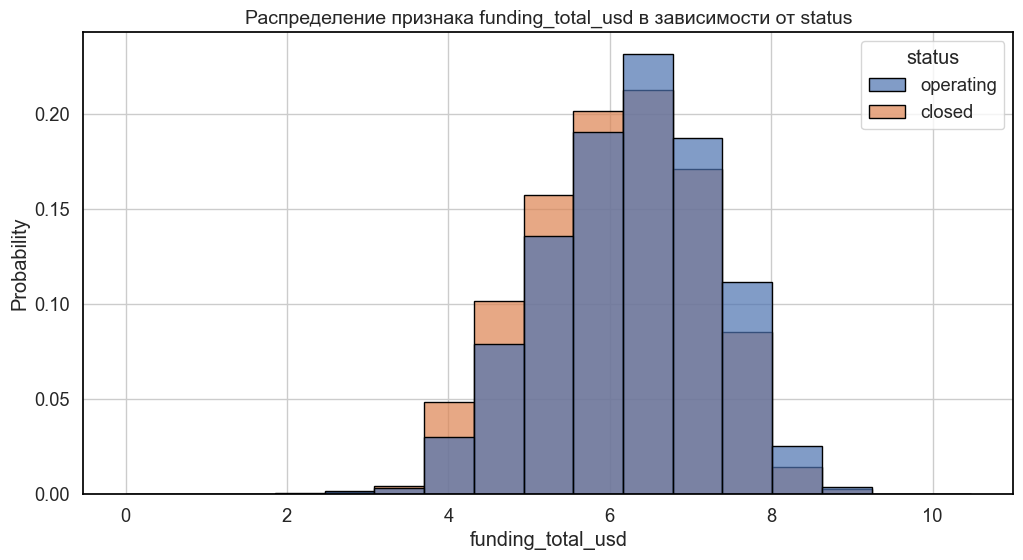

Медианный уровень финансирования у открытых стартапов -  2000000.0
Медианный уровень финансирования у закрытых стартапов -  1300000.0


In [25]:
describe_column(np.log10(data_train['funding_total_usd']),
                hue=data_train['status'], alpha=0.7)
print('Медианный уровень финансирования у открытых стартапов - ',
      data_train.query('status=="operating"')['funding_total_usd'].median())
print('Медианный уровень финансирования у закрытых стартапов - ',
      data_train.query('status=="closed"')['funding_total_usd'].median())

In [26]:
results_ = ttest_ind(np.log10(data_train.query('status=="operating"')['funding_total_usd'].dropna()),
                       np.log10(data_train.query('status=="closed"')['funding_total_usd'].dropna()),
                       equal_var=False)
print('p-значение:', results_.pvalue)

p-значение: 2.3572952626580697e-25


- Распределение похоже на логнормальное, попробуем посмотреть на преобразованный признак
- Медианный объем инвестиций 1.8 млн USD
- Распределения стартапов по объему финансирования различны
- Медианный объем у открытых стартапов - 2.0 млн USD
- Медианный объем у закрытых стартапов - 1.3 млн USD

In [27]:
data_train['funding_total_usd_log'] = np.log10(data_train['funding_total_usd'])
data_test['funding_total_usd_log'] = np.log10(data_test['funding_total_usd'])

### `lifetime`

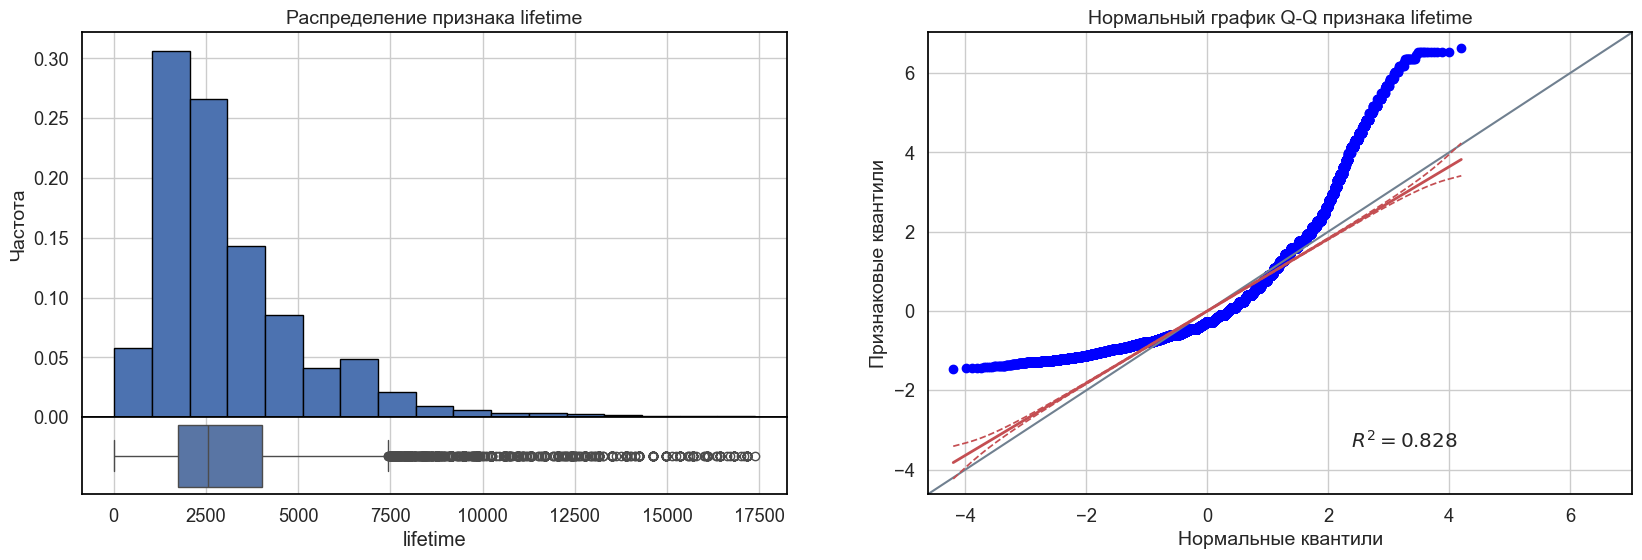

,count,mean,std,min,25%,50%,75%,max
lifetime,52516.0,3140.828129,2147.82107,19.0,1739.0,2557.0,4018.0,17378.0


In [28]:
describe_column(data_train['lifetime'])

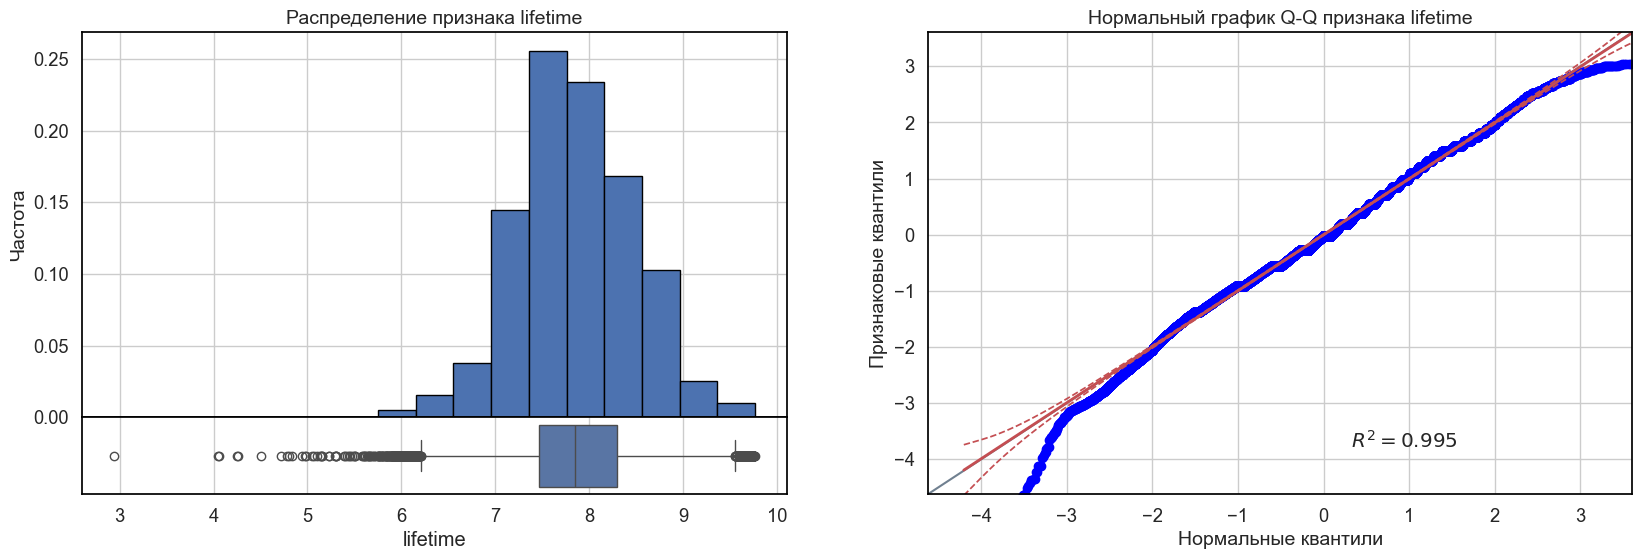

,count,mean,std,min,25%,50%,75%,max
lifetime,52516.0,7.858161,0.622682,2.944439,7.461066,7.84659,8.29854,9.76296


In [29]:
describe_column(np.log(data_train['lifetime']))

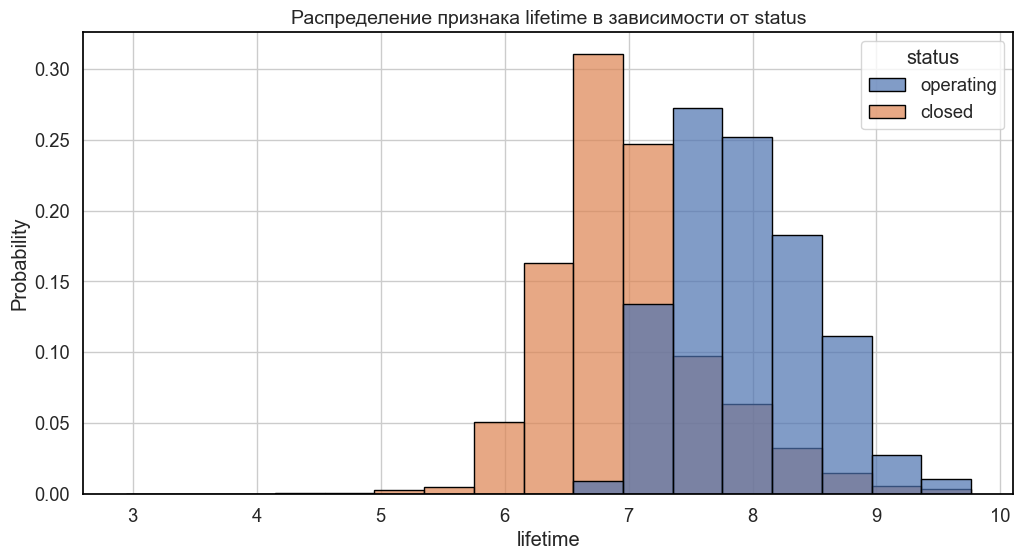

Медианное время жизни у открытых стартапов -  2579.0
Медианное время жизни у закрытых стартапов -  1013.0


In [30]:
describe_column(np.log(data_train['lifetime']), hue=data_train['status'], alpha=0.7)
print('Медианное время жизни у открытых стартапов - ',
      data_train.query('status=="operating"')['lifetime'].median())
print('Медианное время жизни у закрытых стартапов - ',
      data_train.query('status=="closed"')['lifetime'].median())

In [31]:
results_ = ttest_ind(np.log(data_train.query('status=="operating"')['lifetime']),
                       np.log(data_train.query('status=="closed"')['lifetime']),
                       equal_var=False, alternative='greater')
print('p-значение:', results_.pvalue)

p-значение: 0.0


- Распределение признака похоже на логнормальное
- Медианное время жизни 2557 дней
- Есть статистически значимое различие в признаке в зависимости от статуса стартапа
- Медианное время жизни у открытых стартапов -  2579 дней
- Медианное время жизни у закрытых стартапов -  1013 дней

In [32]:
data_train['lifetime_log'] = np.log10(data_train['lifetime'])
data_test['lifetime_log'] = np.log10(data_test['lifetime'])

### `funding_rounds`

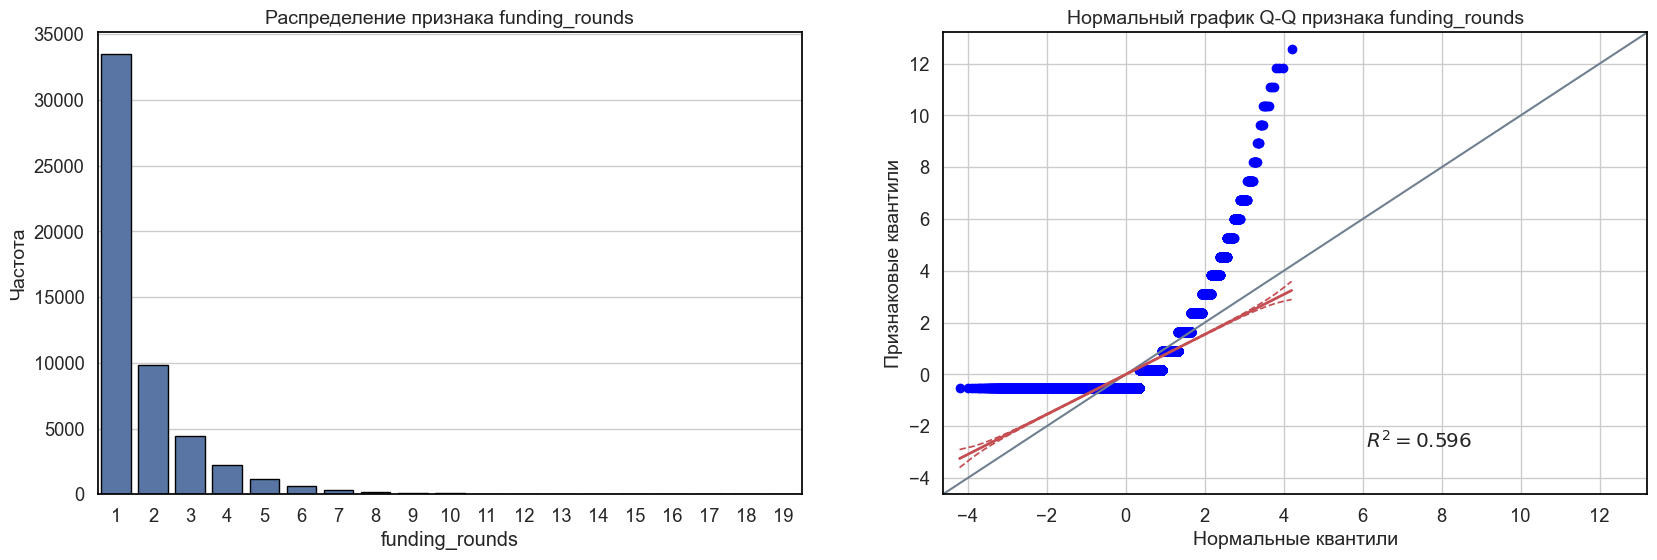

,count,mean,std,min,25%,50%,75%,max
funding_rounds,52516.0,1.74067,1.374522,1.0,1.0,1.0,2.0,19.0


In [33]:
describe_column(data_train['funding_rounds'])

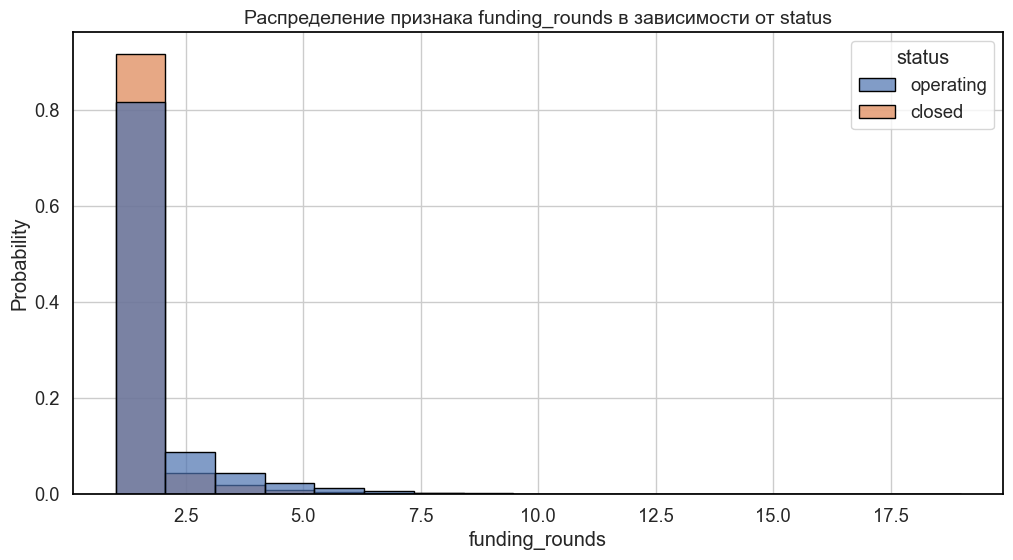

In [34]:
describe_column(data_train['funding_rounds'],
                hue=data_train['status'], alpha=0.7)

- Около 33 тыс. стартапов только с 1 раундом инвестиций
- Есть небольшая разница в распределении в зависимости от статуса стартапа, с 1 раундом стартап вероятнее закрыт
- Будем использовать как есть

### Географические признаки `country_code`, `state_code`, `region` и `city`

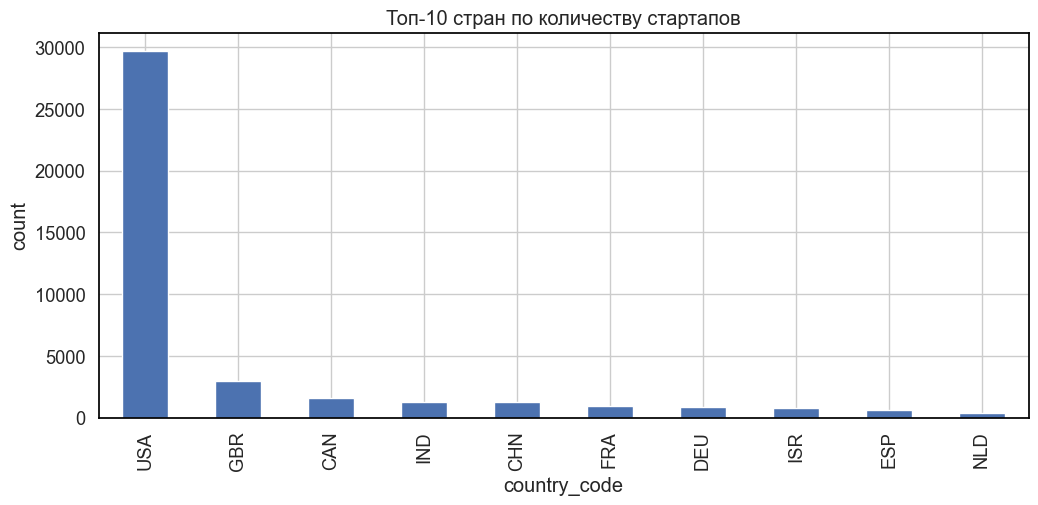

In [35]:
(data_train['country_code']
 .value_counts()
 .head(10)
 .plot(kind='bar',
       title='Топ-10 стран по количеству стартапов',
       ylabel='count',
       figsize=(12,5))
);

На США приходится больше половины стартапов в выборке, на втором месте Англия, где стартапов примерно в десять раз меньше. Объединим США и штаты страны. Другие штаты пересекаются между странами, например штат 7

In [36]:
data_train.query('state_code=="7"')['country_code'].value_counts().head(5)

country_code
IRL    271
NLD    186
IND    168
ARG    137
AUS    104
Name: count, dtype: int64

In [37]:
data_train['country_code_upd'] = (
    data_train['country_code'] +
    (data_train['country_code'] == 'USA').astype(int) *
    ('_' + data_train['state_code'].fillna(''))
)

data_test['country_code_upd'] = (
    data_test['country_code'] +
    (data_test['country_code'] == 'USA').astype(int) *
    ('_' + data_test['state_code'].fillna(''))
)

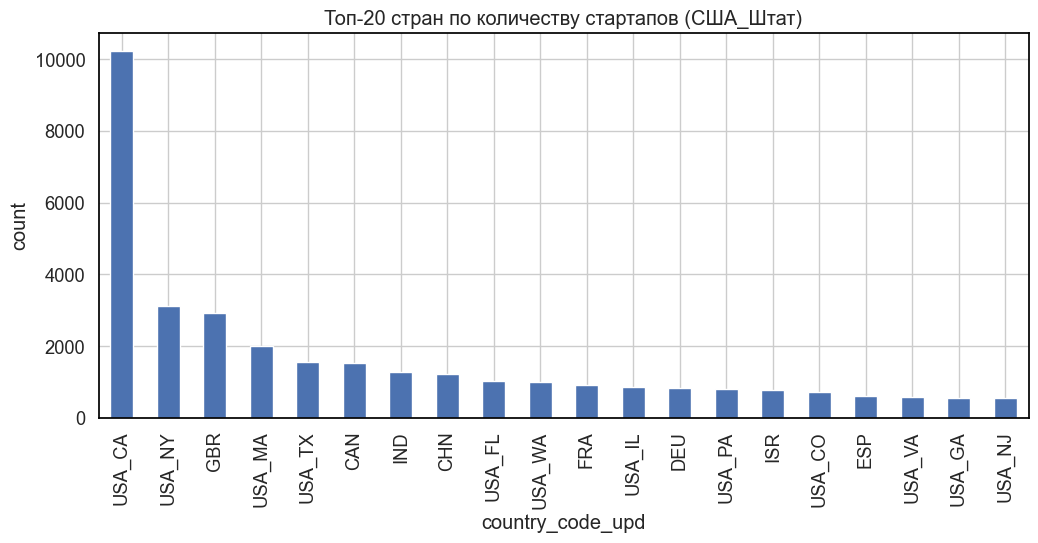

In [38]:
(data_train['country_code_upd']
 .value_counts()
 .head(20)
 .plot(kind='bar',
       title='Топ-20 стран по количеству стартапов (США_Штат)',
       ylabel='count',
       figsize=(12,5))
);

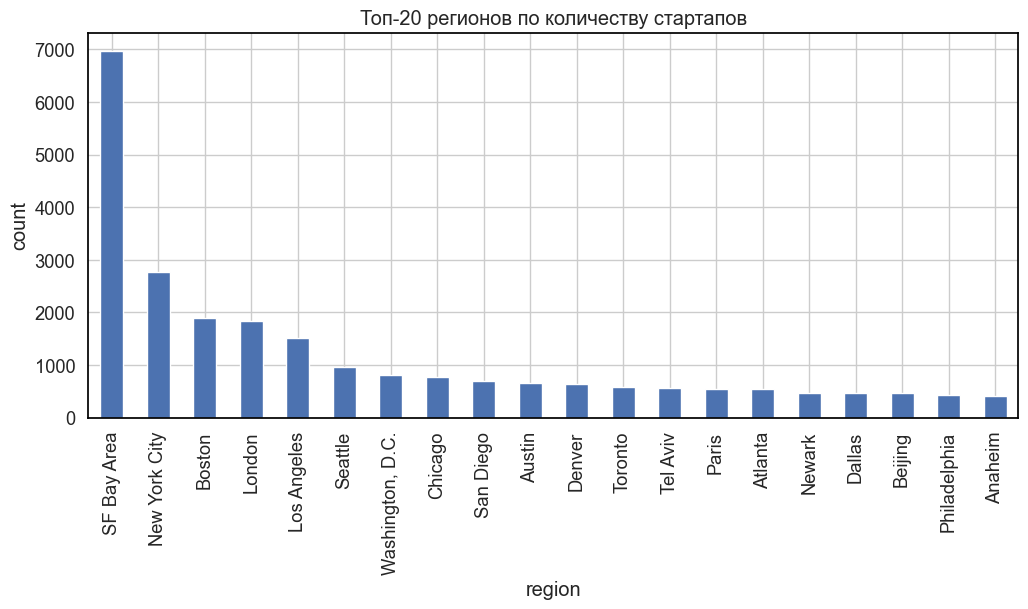

In [39]:
(data_train['region']
 .value_counts()
 .head(20)
 .plot(kind='bar',
       title='Топ-20 регионов по количеству стартапов',
       ylabel='count',
       figsize=(12,5))
);

Ничего особенного, очевидно, что почти все регионы из топ-20 будут в США. Так же есть столицы других стран - Лондон, Париж и Тель-Авив. Так же очевидно, что больше всего стартапов в Сан-Франциско. Похожая ситуация и по топ-20 городов

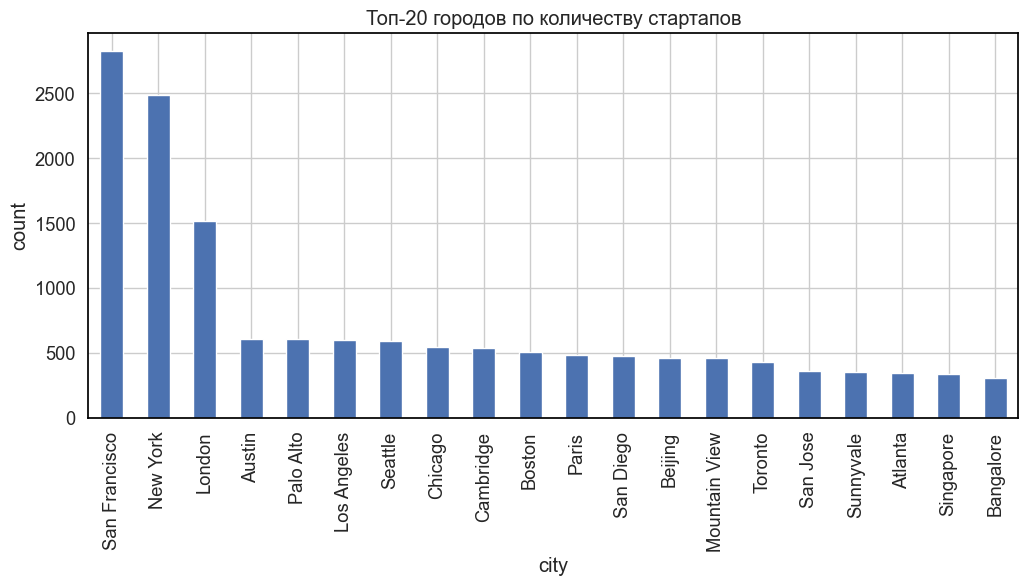

In [40]:
(data_train['city']
 .value_counts()
 .head(20)
 .plot(kind='bar',
       title='Топ-20 городов по количеству стартапов',
       ylabel='count',
       figsize=(12,5))
);

Посмотрим на ситуацию в Калифорнии. Возьмем топ-5 городов и разобьем значение `USA_CA` по топ-5 городам и оставшиеся оставим в общем признаке

In [41]:
data_train.query('country_code_upd=="USA_CA"')['city'].value_counts().head(5).index.tolist()

['San Francisco', 'Palo Alto', 'Los Angeles', 'San Diego', 'Mountain View']

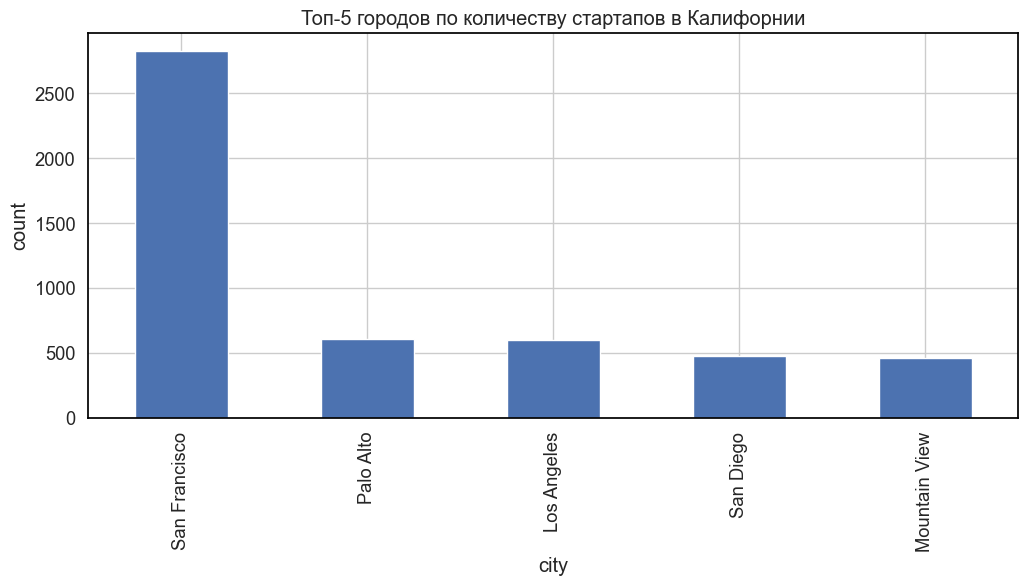

In [42]:
(data_train.query('country_code_upd=="USA_CA"')['city']
 .value_counts()
 .head(5)
 .plot(kind='bar',
       title='Топ-5 городов по количеству стартапов в Калифорнии',
       ylabel='count',
       figsize=(12,5))
);

In [43]:
data_train['country_code_upd'] = (
    data_train['country_code_upd'] +
    (data_train['country_code_upd'] == 'USA_CA').astype(int) *
    (data_train['city'].isin(['San Francisco',
                              'Palo Alto',
                              'Los Angeles',
                              'San Diego',
                              'Mountain View'])).astype(int) *
    ('_' + data_train['city'].fillna(''))
)

data_test['country_code_upd'] = (
    data_test['country_code_upd'] +
    (data_test['country_code_upd'] == 'USA_CA').astype(int) *
    (data_test['city'].isin(['San Francisco',
                              'Palo Alto',
                              'Los Angeles',
                              'San Diego',
                              'Mountain View'])).astype(int) *
    ('_' + data_test['city'].fillna(''))
)

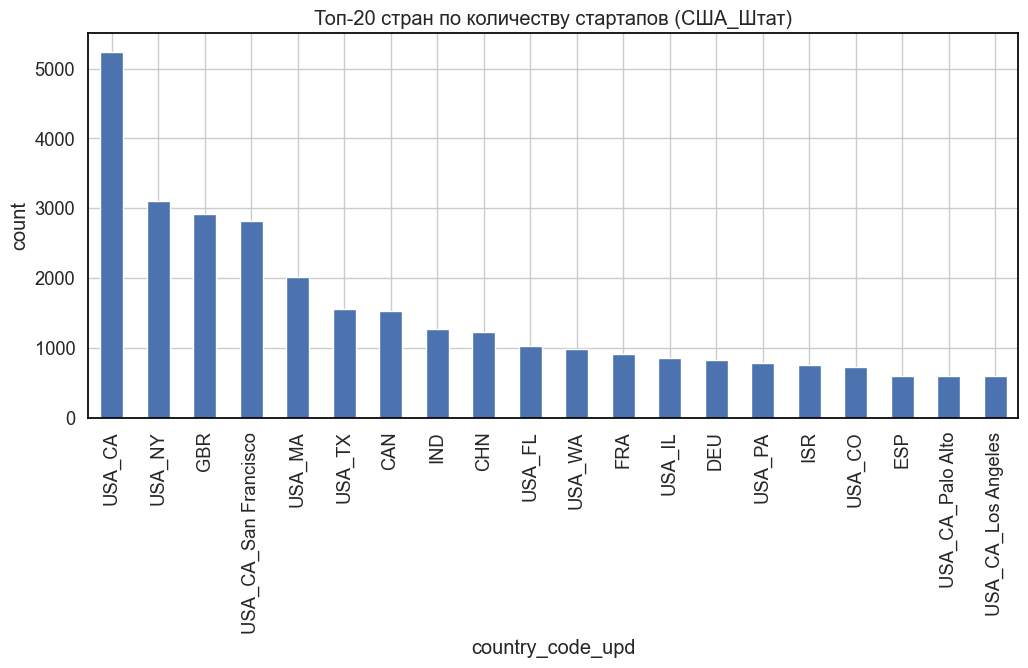

In [44]:
(data_train['country_code_upd']
 .value_counts()
 .head(20)
 .plot(kind='bar',
       title='Топ-20 стран по количеству стартапов (США_Штат)',
       ylabel='count',
       figsize=(12,5))
);

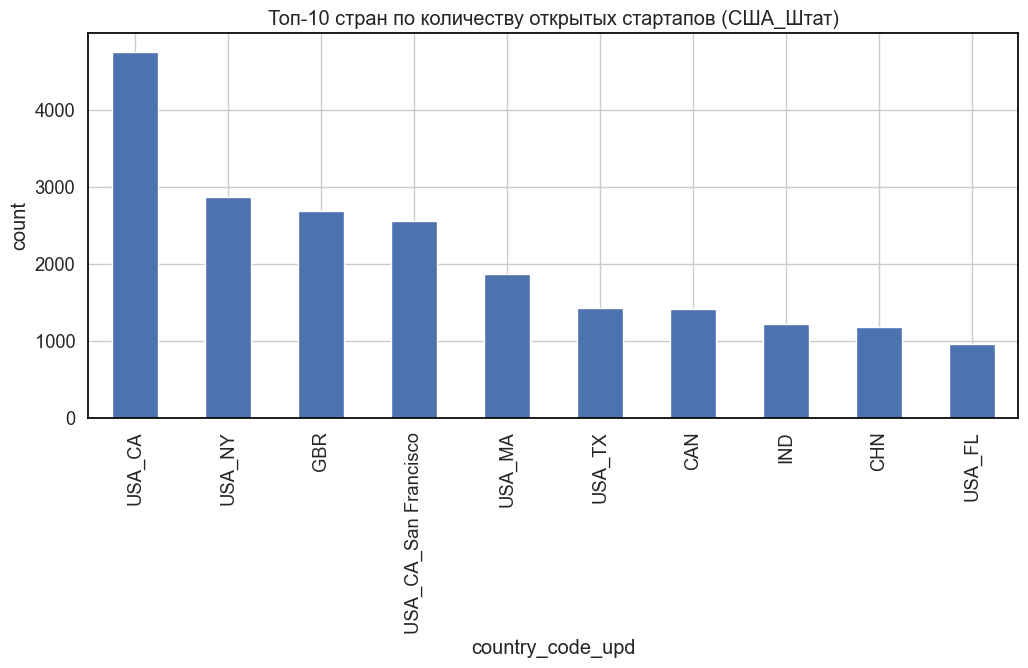

In [45]:
(data_train.query('status=="operating"')['country_code_upd']
 .value_counts()
 .head(10)
 .plot(kind='bar',
       title='Топ-10 стран по количеству открытых стартапов (США_Штат)',
       ylabel='count',
       figsize=(12,5))
);

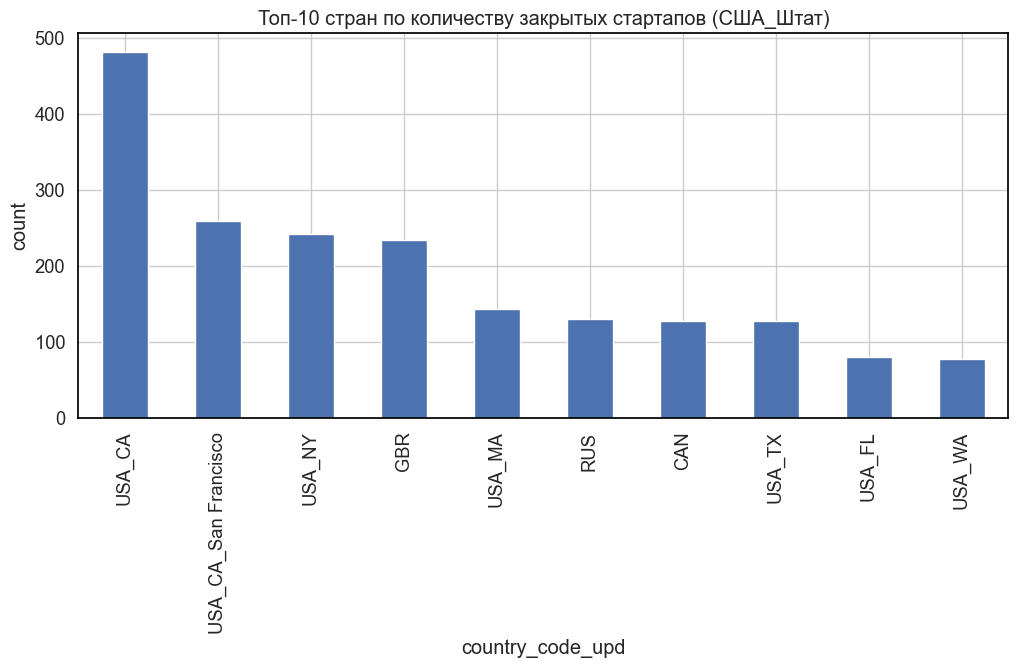

In [46]:
(data_train.query('status=="closed"')['country_code_upd']
 .value_counts()
 .head(10)
 .plot(kind='bar',
       title='Топ-10 стран по количеству закрытых стартапов (США_Штат)',
       ylabel='count',
       figsize=(12,5))
);

- Заменили все 4 географических признака на `country_code_upd`, где данные рапспределены более равномерно
- Больше всего стартапов в США - около 30 000
- Около 10 000 приходится на Калифорнию
- Около 7 000 приходится на залив Сан-Франциско
- Около 2 600 стартапов на сам Сан-Франциско, что сравнимо или больше, чем в остальных странах
- Больше всего работающих стартапов в США (Калифорния, Нью-Йорк) и Англии - от 4000 до 2500
- Больше всего закрытых стартапов так же в США и Англии - от 500 до 200, так же недалеко расположилась Россия со 120 стартапами

### `category`

Попробуем выделить основные 100 категорий по частоте и разметить записи. Разобьем по `|`, затем по `' '`, если применимо и будем брать первое значение. Значимость будем считать частотой встречаемости значения, если в `category_list` будет два разных значения из списка, то запишется чаще встречаемое.

In [47]:
df_cat = pd.DataFrame(
    data_train['category_list']
    .dropna()
    .str
    .split('|')
    .explode()
    .str
    .split(' ')
    .str[0]
    .value_counts()).reset_index()
df_cat = df_cat['category_list']
df_cat.head(5)

0         Software
1           Mobile
2           Social
3           Health
4    Biotechnology
Name: category_list, dtype: object

In [48]:
data_train['category_general'] = data_train['category_list'].apply(
    lambda x:
    np.NaN if pd.isnull(x)
    else ('Other' if df_cat.isin(re.split(r'[| ]+', x)).sum()==0
          else df_cat[df_cat.isin(re.split(r'[| ]+', x)).idxmax()]))

data_test['category_general'] = data_test['category_list'].apply(
    lambda x:
    np.NaN if pd.isnull(x)
    else ('Other' if df_cat.isin(re.split(r'[| ]+', x)).sum()==0
          else df_cat[df_cat.isin(re.split(r'[| ]+', x)).idxmax()]))

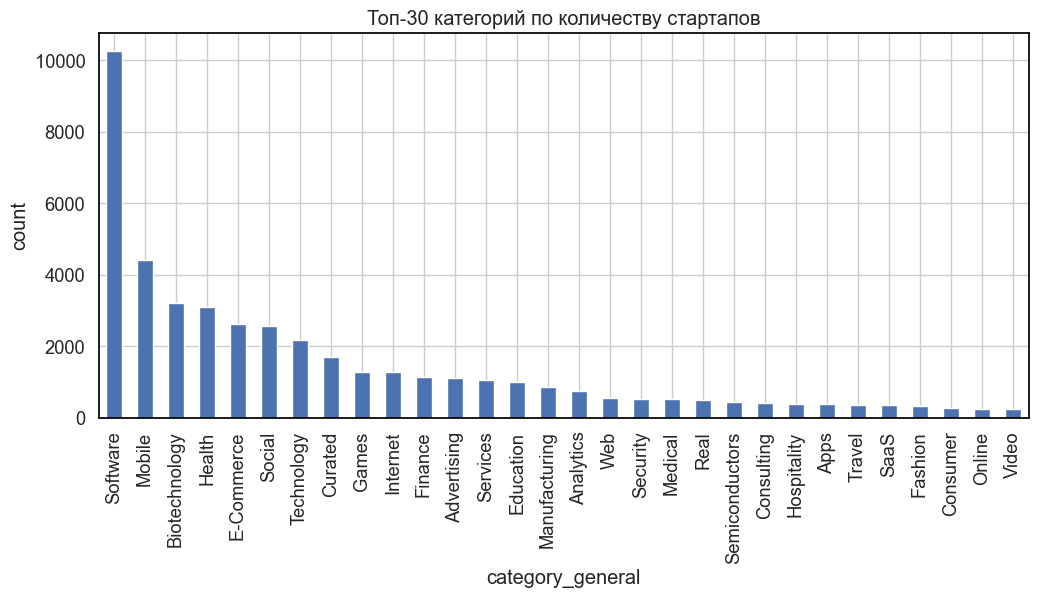

In [49]:
(data_train['category_general']
 .value_counts()
 .head(30)
 .plot(kind='bar',
       title='Топ-30 категорий по количеству стартапов',
       ylabel='count',
       figsize=(12,5))
);

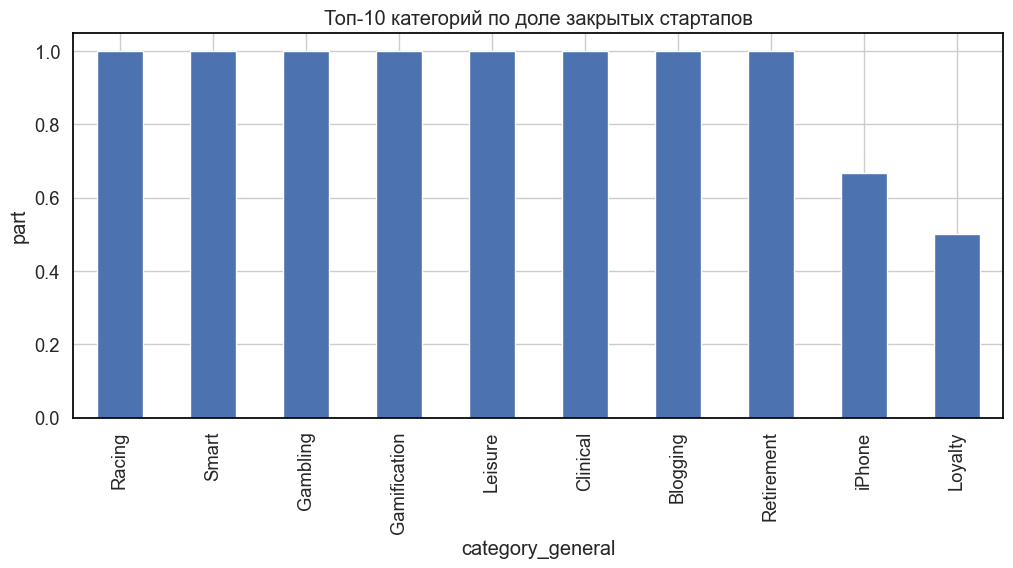

In [50]:
(
    (data_train.query('status=="closed"')['category_general'].value_counts() /
     data_train['category_general'].value_counts())
    .sort_values(ascending=False)
     .head(10)
     .plot(kind='bar',
           title='Топ-10 категорий по доле закрытых стартапов',
           ylabel='part',
           figsize=(12,5))
);

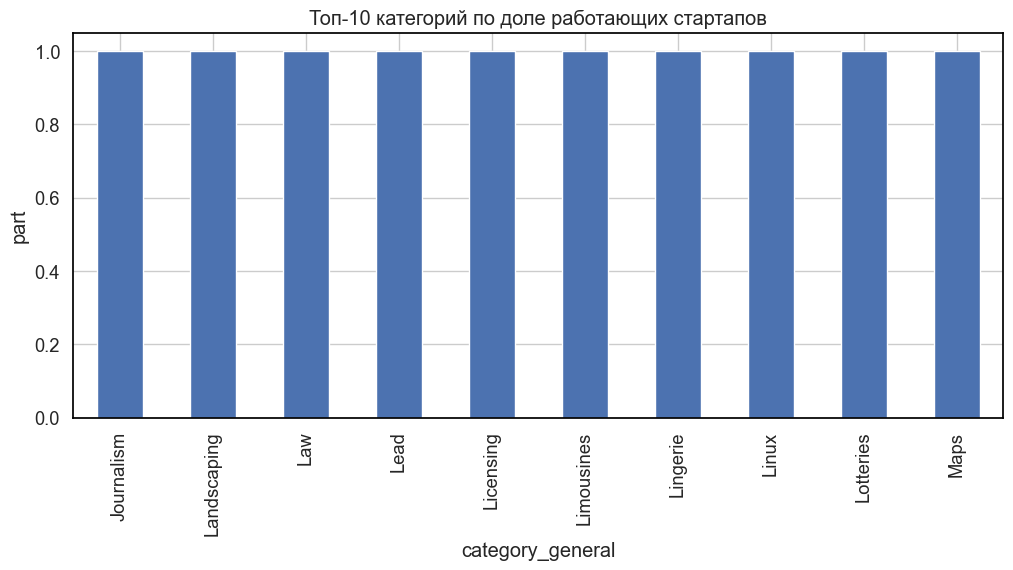

In [51]:
(
    (data_train.query('status=="operating"')['category_general'].value_counts() /
     data_train['category_general'].value_counts())
    .sort_values(ascending=False)
     .head(10)
     .plot(kind='bar',
           title='Топ-10 категорий по доле работающих стартапов',
           ylabel='part',
           figsize=(12,5))
);

Добавим столбец с долей закрытых стартапов из топ-100 категорий

In [52]:
data_train['category_general_100'] = data_train['category_list'].apply(
    lambda x:
    np.NaN if pd.isnull(x)
    else ('Other' if df_cat.head(100).isin(re.split(r'[| ]+', x)).sum()==0
          else df_cat[df_cat.head(100).isin(re.split(r'[| ]+', x)).idxmax()]))

data_test['category_general_100'] = data_test['category_list'].apply(
    lambda x:
    np.NaN if pd.isnull(x)
    else ('Other' if df_cat.head(100).isin(re.split(r'[| ]+', x)).sum()==0
          else df_cat[df_cat.head(100).isin(re.split(r'[| ]+', x)).idxmax()]))

In [53]:
cat_closed_part = (
    data_train.query('status=="closed"')['category_general_100'].value_counts() /
     data_train['category_general_100'].value_counts()).fillna(0)

In [54]:
data_train['category_closed_part'] = data_train['category_general_100'].apply(
    lambda x:
    cat_closed_part[x] if cat_closed_part.index.isin([x]).any()
    else -1)

data_test['category_closed_part'] = data_test['category_general_100'].apply(
    lambda x:
    cat_closed_part[x] if cat_closed_part.index.isin([x]).any()
    else -1)

data_train.drop('category_general_100', axis=1, inplace=True)
data_test.drop('category_general_100', axis=1, inplace=True)

- Добавили признак `category_general` из топ-100 категорий
- Больше всего стартапов в области `Software` чуть больше 10000
- Больше всего доля закрытых стартапов в области `iPhone`, `Television`, `Reviews`
- Больше всего доля открытых стартапов в области `IT`, `FinTech`, `Data`

### `first_funding_at` и `last_funding_at`

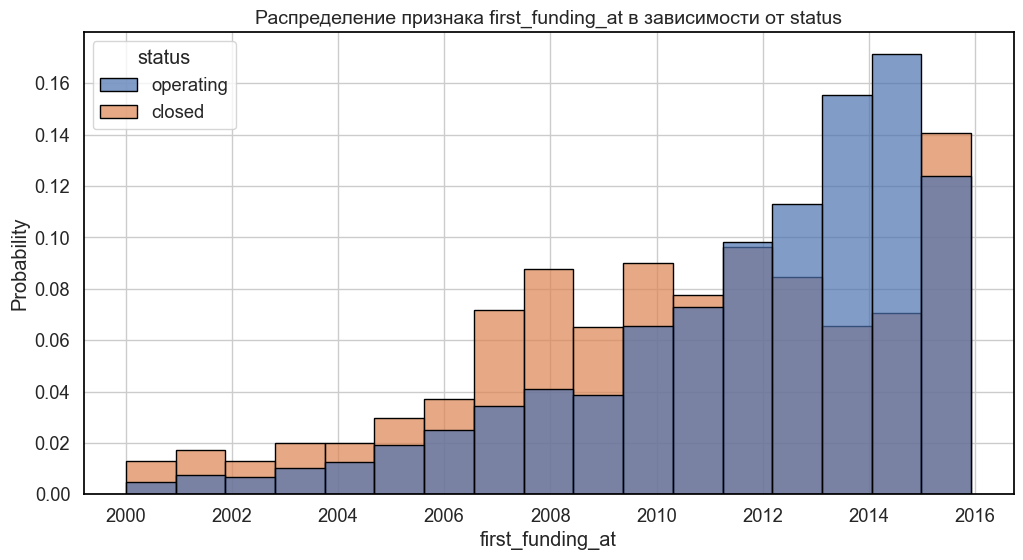

Медианный начальный год финансирования у открытых стартапов -  2012-09-16 00:00:00
Медианный начальный год финансирования у закрытых стартапов -  2010-08-10 00:00:00


In [55]:
describe_column(data_train.query('first_funding_at>2000')['first_funding_at'],
                hue=data_train['status'], alpha=0.7)
print('Медианный начальный год финансирования у открытых стартапов - ',
      data_train.query('status=="operating"')['first_funding_at'].median())
print('Медианный начальный год финансирования у закрытых стартапов - ',
      data_train.query('status=="closed"')['first_funding_at'].median())

- Стартапы получившие первое финансирование до 2012 чаще закрывались
- Есть увеличение закрытий в районе 2008 года, когда случился экономический кризис
- В районе 2014 года бум стартапов, ближе к 2016 ситауция снова выравнивается

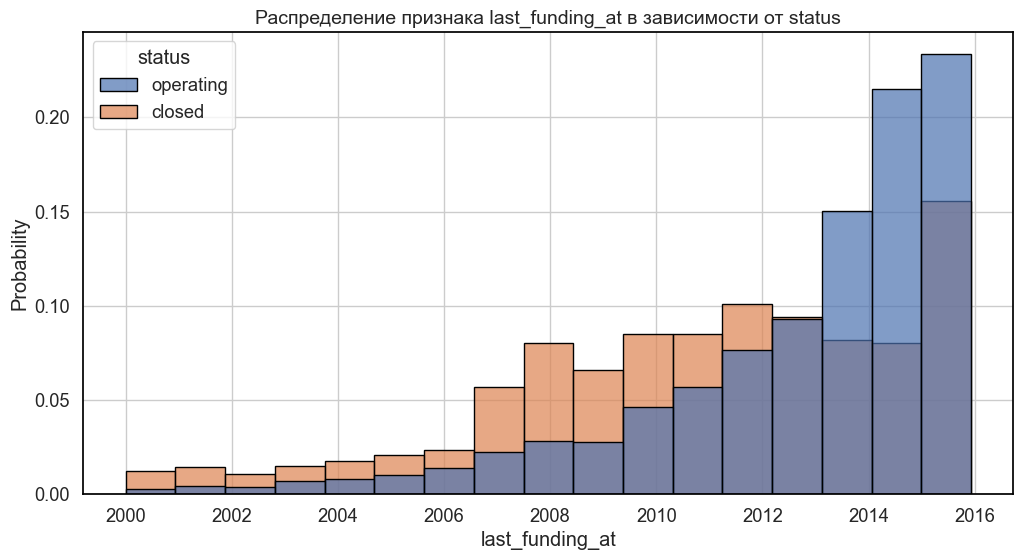

Медианный год последнего финансирования у открытых стартапов -  2013-10-16 00:00:00
Медианный год последнего финансирования у закрытых стартапов -  2011-04-01 00:00:00


In [56]:
describe_column(data_train.query('last_funding_at>2000')['last_funding_at'],
                hue=data_train['status'], alpha=0.7)
print('Медианный год последнего финансирования у открытых стартапов - ',
      data_train.query('status=="operating"')['last_funding_at'].median())
print('Медианный год последнего финансирования у закрытых стартапов - ',
      data_train.query('status=="closed"')['last_funding_at'].median())

Здесь ситуация аналогична с небольшим гэпом в 1 год. Стартапы больше закрывались после кризиса

Добавим признаки `first_funding_time`, `last_funding_time` и `between_funding_time`, а также год последнего финансирования

In [57]:
data_train['first_funding_time'] = (pd.to_datetime('2018-01-01')
                                    - data_train['first_funding_at']).dt.days.astype(int)
data_train['last_funding_time'] = (pd.to_datetime('2018-01-01')
                                   - data_train['last_funding_at']).dt.days.astype(int)
data_train['between_funding_time'] = (data_train['last_funding_at']
                                      - data_train['first_funding_at']).dt.days.astype(int)
data_train['last_funding_year'] = data_train['last_funding_at'].dt.year

data_test['first_funding_time'] = (pd.to_datetime('2018-01-01')
                                    - data_test['first_funding_at']).dt.days.astype(int)
data_test['last_funding_time'] = (pd.to_datetime('2018-01-01')
                                   - data_test['last_funding_at']).dt.days.astype(int)
data_test['between_funding_time'] = (data_test['last_funding_at']
                                      - data_test['first_funding_at']).dt.days.astype(int)
data_test['last_funding_year'] = data_test['last_funding_at'].dt.year

`first_funding_time` и `last_funding_time` оба логнормальные

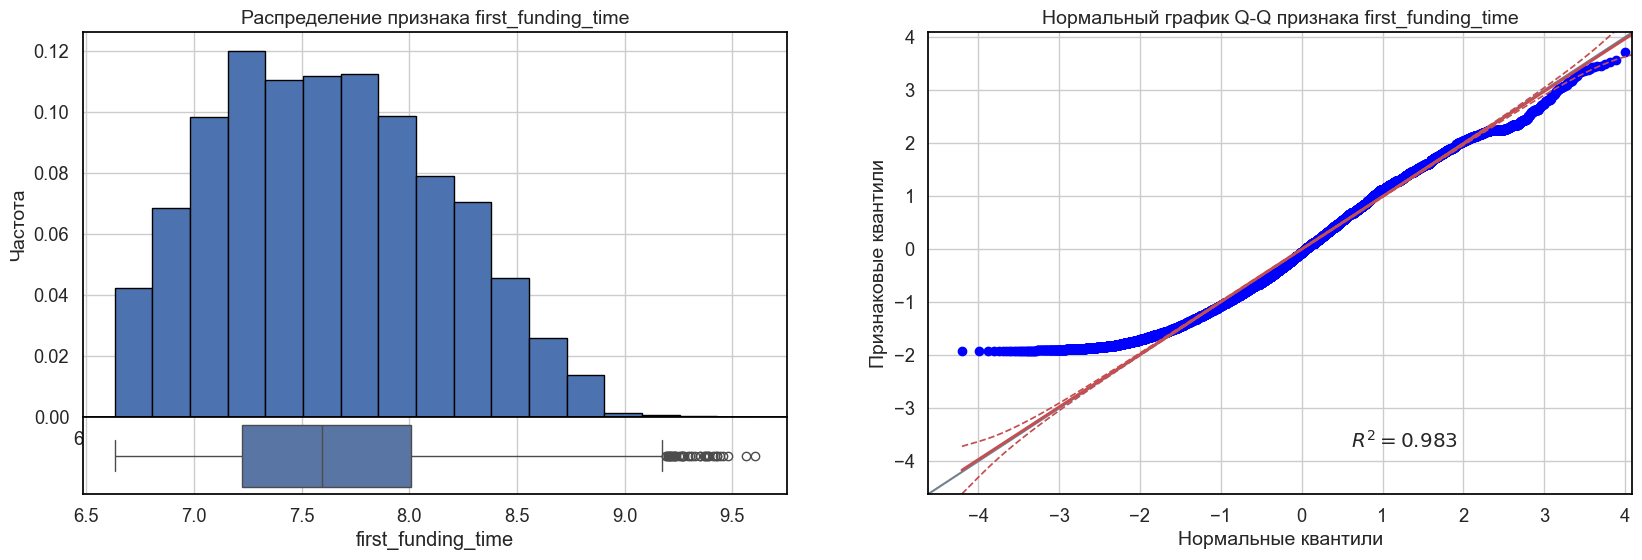

,count,mean,std,min,25%,50%,75%,max
first_funding_time,52516.0,7.627847,0.519575,6.630683,7.223296,7.594884,8.007367,9.605149


In [58]:
describe_column(np.log(data_train['first_funding_time']))

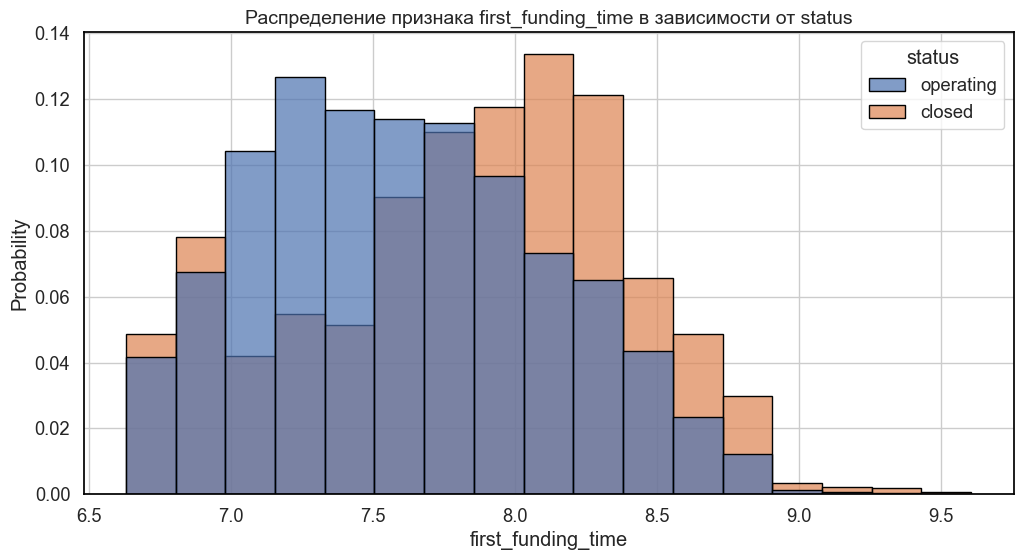

Медианное количество дней после первого финансирования у открытых стартапов -  1933.0
Медианное количество дней после первого финансирования у закрытых стартапов -  2701.0


In [59]:
describe_column(np.log(data_train['first_funding_time']),
                hue=data_train['status'], alpha=0.7)
print('Медианное количество дней после первого финансирования у открытых стартапов - ',
      data_train.query('status=="operating"')['first_funding_time'].median())
print('Медианное количество дней после первого финансирования у закрытых стартапов - ',
      data_train.query('status=="closed"')['first_funding_time'].median())

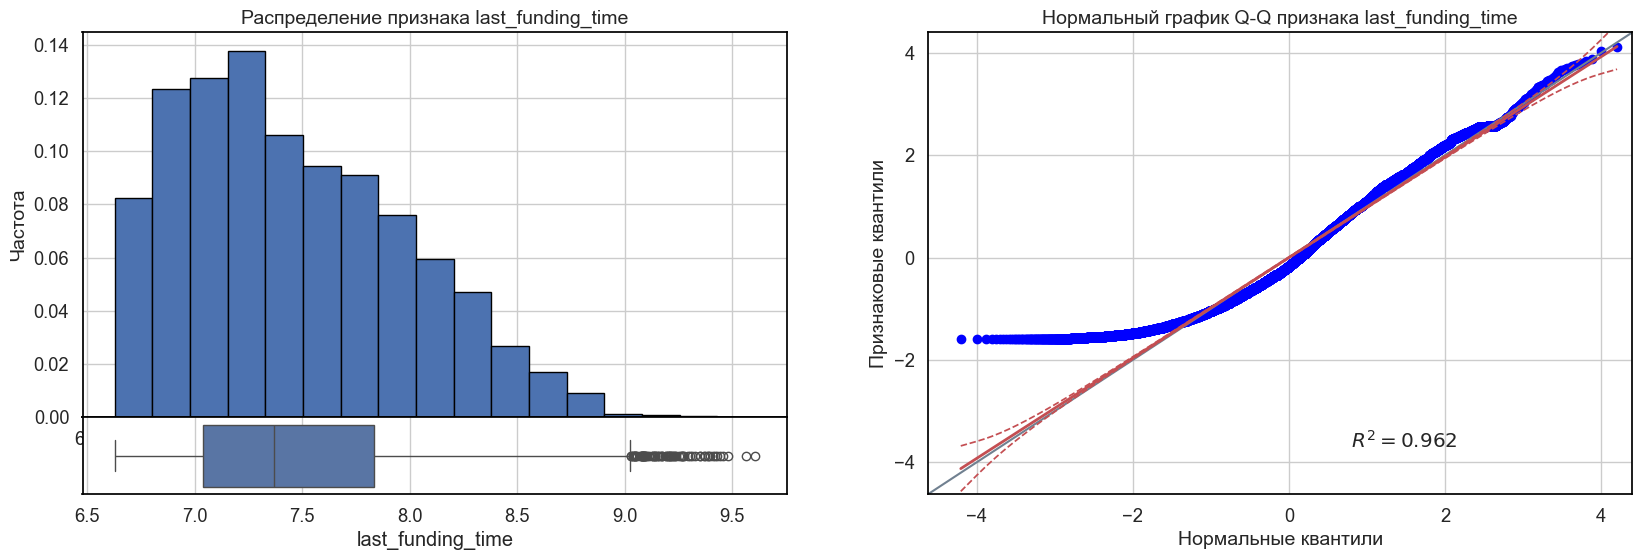

,count,mean,std,min,25%,50%,75%,max
last_funding_time,52516.0,7.461143,0.521056,6.628041,7.03966,7.36834,7.834392,9.605149


In [60]:
describe_column(np.log(data_train['last_funding_time']))

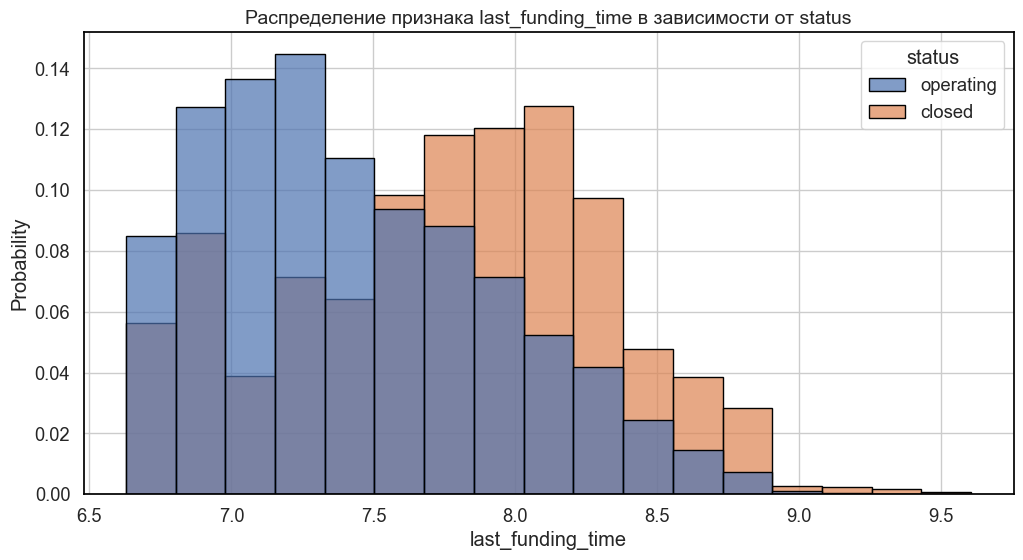

Медианное количество дней после последнего финансирования у открытых стартапов -  1538.0
Медианное количество дней после последнего финансирования у закрытых стартапов -  2467.0


In [61]:
describe_column(np.log(data_train['last_funding_time']),
                hue=data_train['status'], alpha=0.7)
print('Медианное количество дней после последнего финансирования у открытых стартапов - ',
      data_train.query('status=="operating"')['last_funding_time'].median())
print('Медианное количество дней после последнего финансирования у закрытых стартапов - ',
      data_train.query('status=="closed"')['last_funding_time'].median())

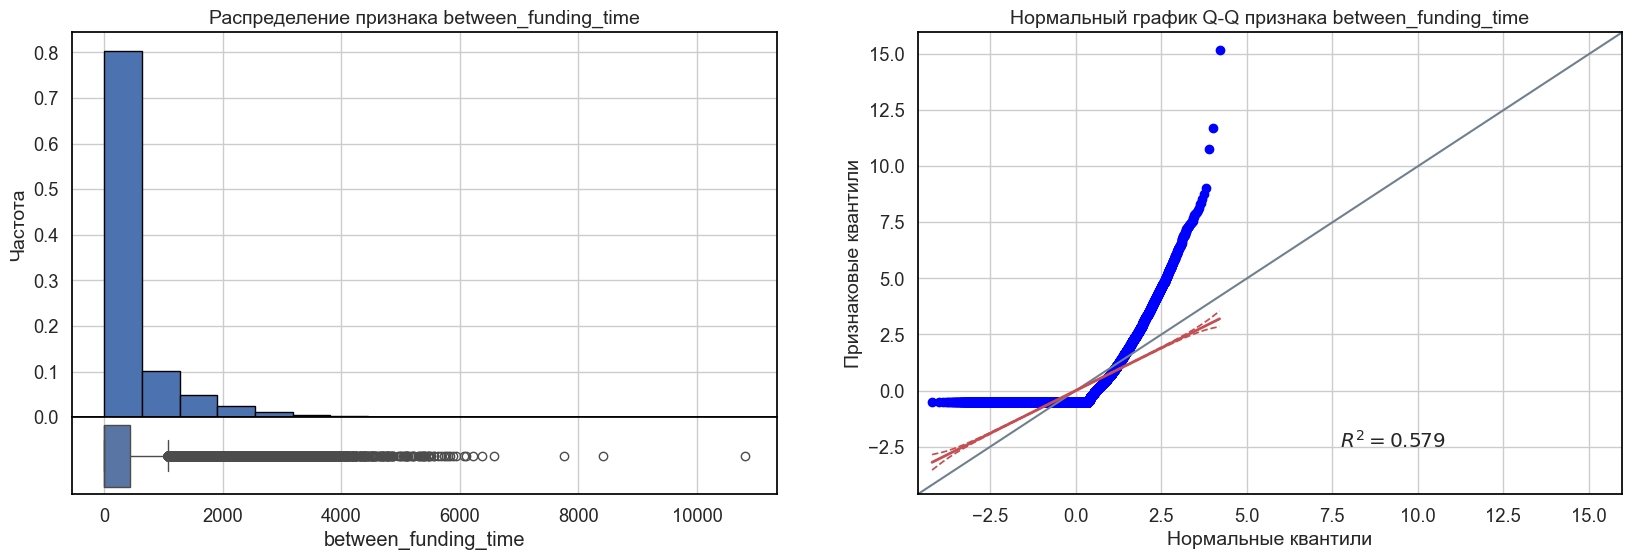

,count,mean,std,min,25%,50%,75%,max
between_funding_time,52516.0,346.488994,688.604389,0.0,0.0,0.0,427.0,10807.0


In [62]:
describe_column(data_train['between_funding_time'])

Так как у нас много стартапов было с одним раундом инвестирования, то логично наблюдать похожую картину

In [63]:
data_train['first_funding_time_log'] = np.log(data_train['first_funding_time'])
data_train['last_funding_time_log'] = np.log(data_train['last_funding_time'])

data_test['first_funding_time_log'] = np.log(data_test['first_funding_time'])
data_test['last_funding_time_log'] = np.log(data_test['last_funding_time'])

Посмотрим на количество стартапов по статусу, когда время с последнего финансирования было больше, чем время жизни стартапов

In [64]:
data_train[(data_train['last_funding_time'] > data_train['lifetime'])]['status'].value_counts()

status
closed       4067
operating    1400
Name: count, dtype: int64

Около 80% закрытых стартапов попали в эту выборку. Причем число открытых стартапов невилико

In [65]:
data_train['lifetime_sub_last_funding'] = (
    data_train['lifetime'] - data_train['last_funding_time'])

data_test['lifetime_sub_last_funding'] = (
    data_test['lifetime'] - data_test['last_funding_time'])

data_train['lifetime_sub_first_funding'] = (
    data_train['lifetime'] - data_train['first_funding_time'])

data_test['lifetime_sub_first_funding'] = (
    data_test['lifetime'] - data_test['first_funding_time'])

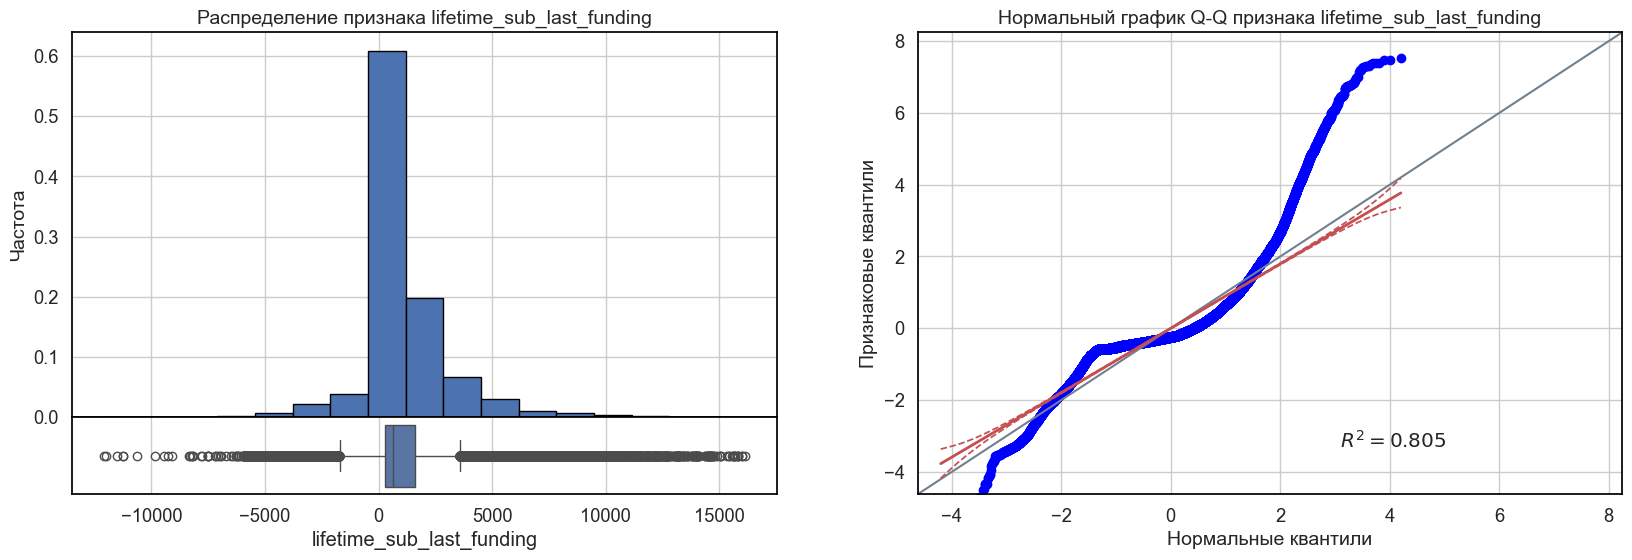

,count,mean,std,min,25%,50%,75%,max
lifetime_sub_last_funding,52516.0,1127.515424,1988.86657,-12072.0,265.0,644.0,1588.0,16117.0


In [66]:
describe_column(data_train['lifetime_sub_last_funding'])

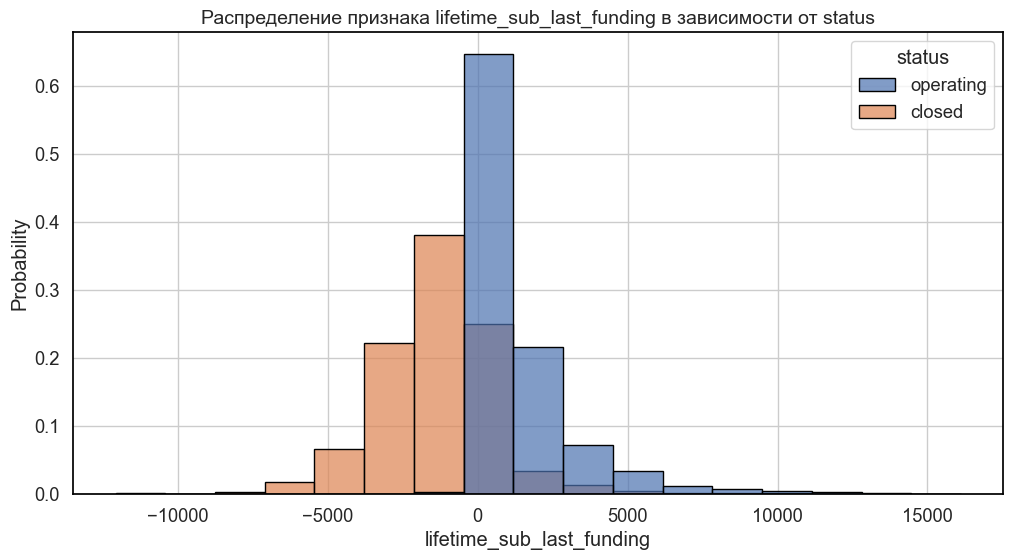

Медианная разница в днях между последним финансированем и временем жизни у открытых стартапов -  706.0
Медианная разница в днях между последним финансированем и временем жизни у закрытых стартапов -  -1231.0


In [67]:
describe_column(data_train['lifetime_sub_last_funding'],
                hue=data_train['status'], alpha=0.7)
print('Медианная разница в днях между последним финансированем и временем жизни у открытых стартапов - ',
      data_train.query('status=="operating"')['lifetime_sub_last_funding'].median())
print('Медианная разница в днях между последним финансированем и временем жизни у закрытых стартапов - ',
      data_train.query('status=="closed"')['lifetime_sub_last_funding'].median())

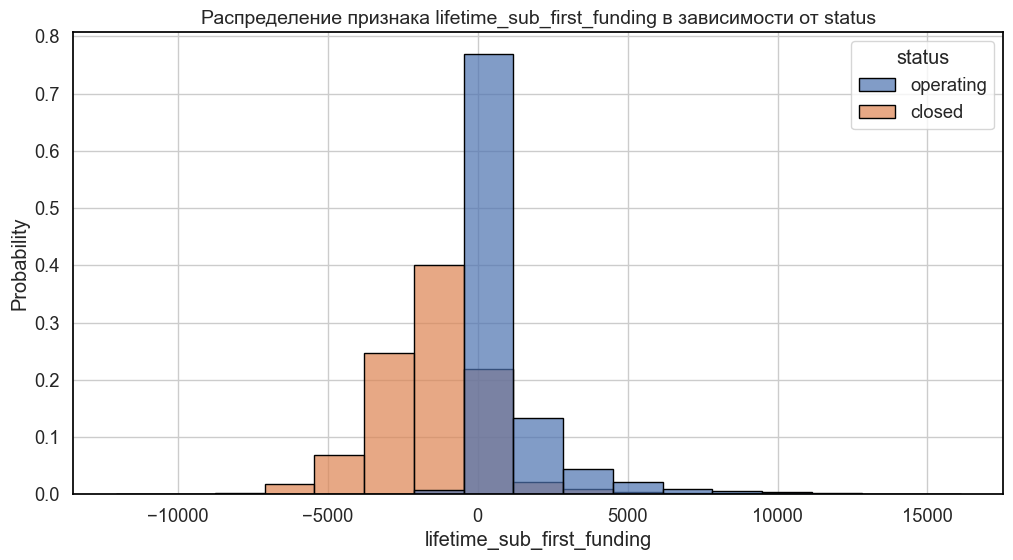

Медианная разница в днях между последним финансированем и временем жизни у открытых стартапов -  490.0
Медианная разница в днях между последним финансированем и временем жизни у закрытых стартапов -  -1428.0


In [68]:
describe_column(data_train['lifetime_sub_first_funding'],
                hue=data_train['status'], alpha=0.7)
print('Медианная разница в днях между последним финансированем и временем жизни у открытых стартапов - ',
      data_train.query('status=="operating"')['lifetime_sub_first_funding'].median())
print('Медианная разница в днях между последним финансированем и временем жизни у закрытых стартапов - ',
      data_train.query('status=="closed"')['lifetime_sub_first_funding'].median())

Видна разница распределений невооруженным глазом

- Стартапы получившие первое финансирование до 2012 чаще закрывались
- Есть увеличение закрытий в районе 2008 года, когда случился экономический кризис
- В районе 2014 года бум стартапов, ближе к 2016 ситауция снова выравнивается
- По последнему финансированию ситуация аналогичная с гэпом в 1 год

- Добавили новые признаки `first_funding_time`, `last_funding_time` и `between_funding_time`, `last_funding_year` и `lifetime_sub_last_funding`
- Медианное количество дней после первого финансирования у открытых стартапов -  1933, у закрытых стартапов -  2701
- Медианное количество дней после последнего финансирования у открытых стартапов -  1538, у закрытых стартапов -  2467
- Медианная разница в днях между последним финансированем и временем жизни у открытых стартапов -  706, у закрытых стартапов -  -1231

### После 2010 года

Так же будем смотреть разрез стартапов открывшихся после 2010 года

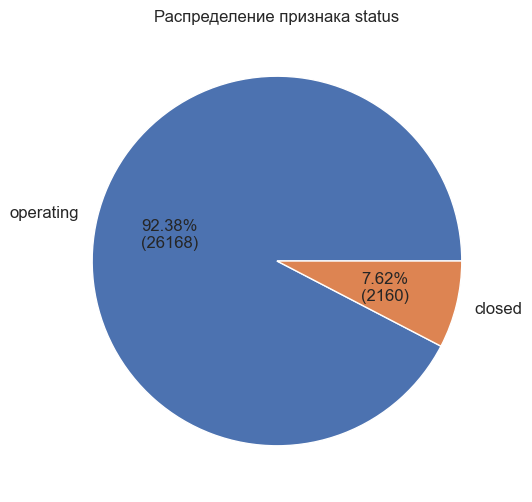

In [69]:
describe_column(data_train.query('founded_at > 2010')['status'])

- После 2010 года работающих стартапов больше на 2 %

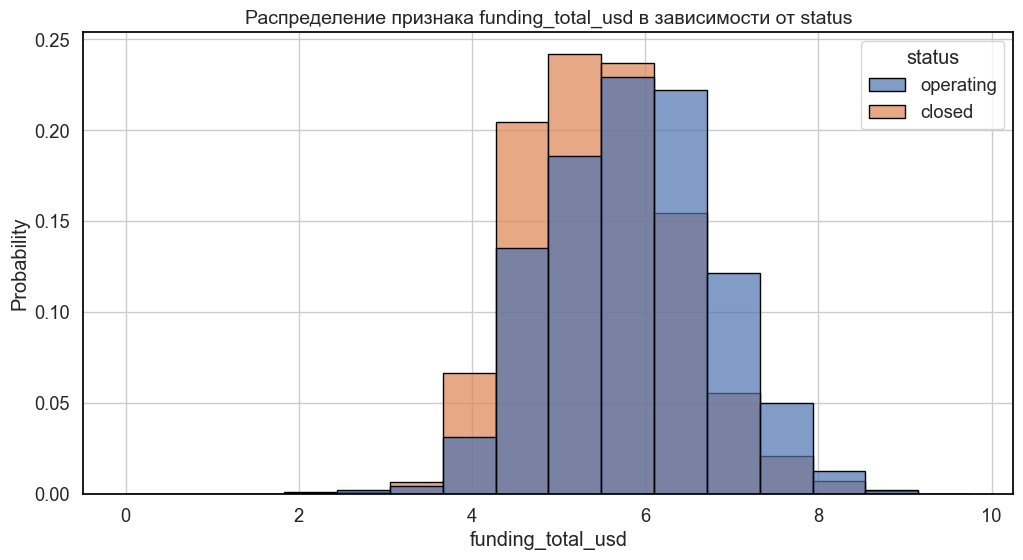

Медианный уровень финансирования у открытых стартапов -  760000.0
Медианный уровень финансирования у закрытых стартапов -  285758.7767787155


In [70]:
describe_column(np.log10(data_train.query('founded_at > 2010')['funding_total_usd']),
                hue=data_train['status'], alpha=0.7)
print('Медианный уровень финансирования у открытых стартапов - ',
      data_train.query('status=="operating" & founded_at > 2010')['funding_total_usd'].median())
print('Медианный уровень финансирования у закрытых стартапов - ',
      data_train.query('status=="closed" & founded_at > 2010')['funding_total_usd'].median())

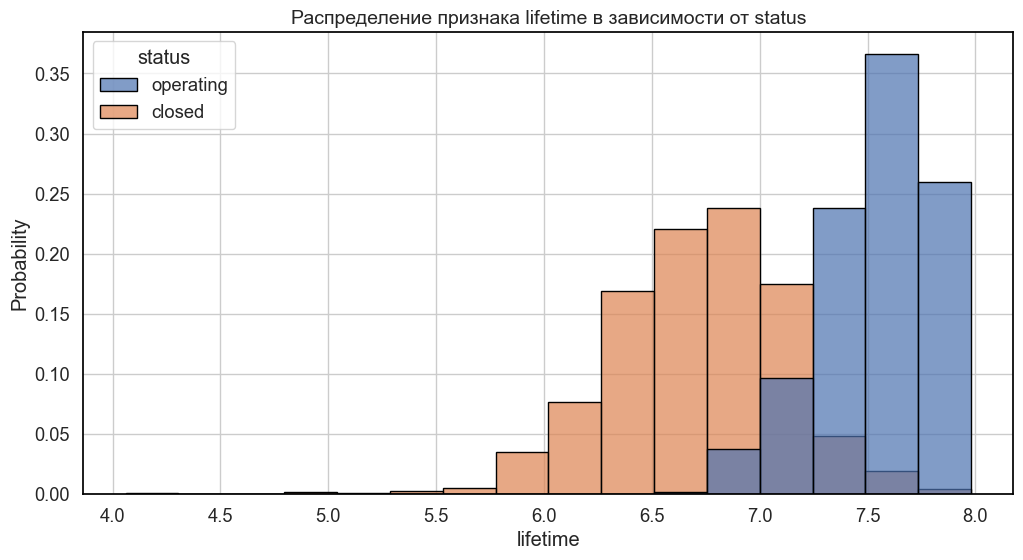

Медианное время жизни у открытых стартапов -  1909.0
Медианное время жизни у закрытых стартапов -  846.0


In [71]:
describe_column(np.log(data_train.query('founded_at > 2010')['lifetime']),
                hue=data_train['status'], alpha=0.7)
print('Медианное время жизни у открытых стартапов - ',
      data_train.query('status=="operating" & founded_at > 2010')['lifetime'].median())
print('Медианное время жизни у закрытых стартапов - ',
      data_train.query('status=="closed" & founded_at > 2010')['lifetime'].median())

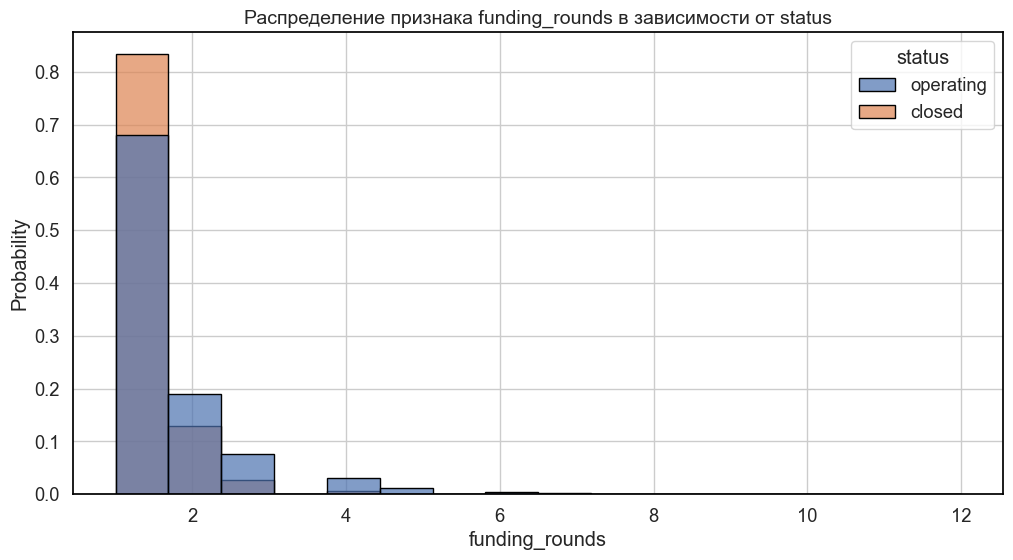

In [72]:
describe_column(data_train.query('founded_at > 2010')['funding_rounds'],
                hue=data_train['status'], alpha=0.7)

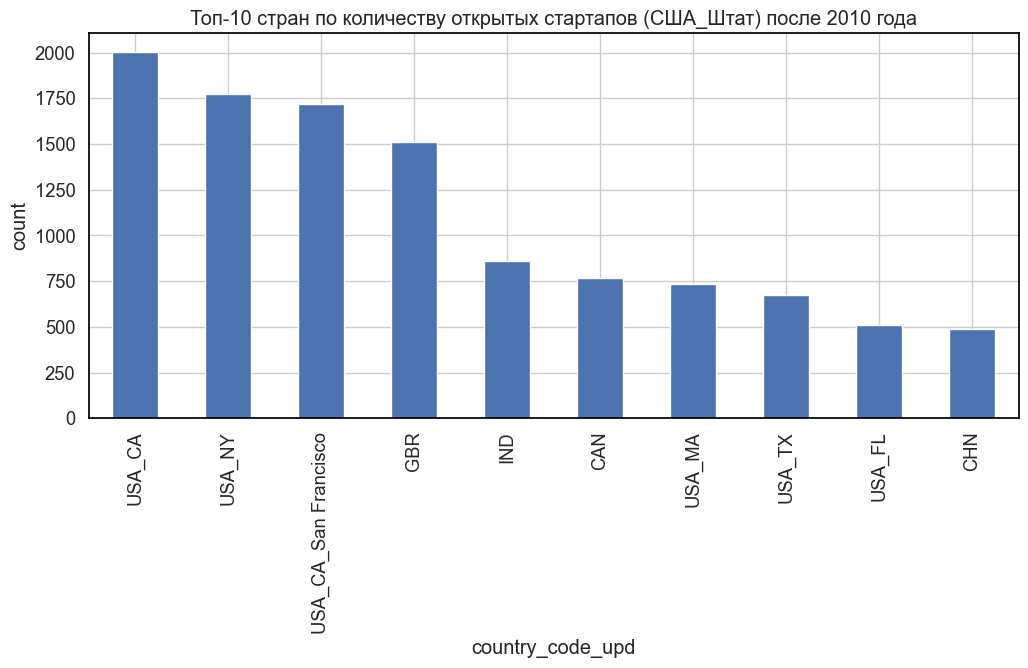

In [73]:
(data_train.query('status=="operating" & founded_at > 2010')['country_code_upd']
 .value_counts()
 .head(10)
 .plot(kind='bar',
       title='Топ-10 стран по количеству открытых стартапов (США_Штат) после 2010 года',
       ylabel='count',
       figsize=(12,5))
);

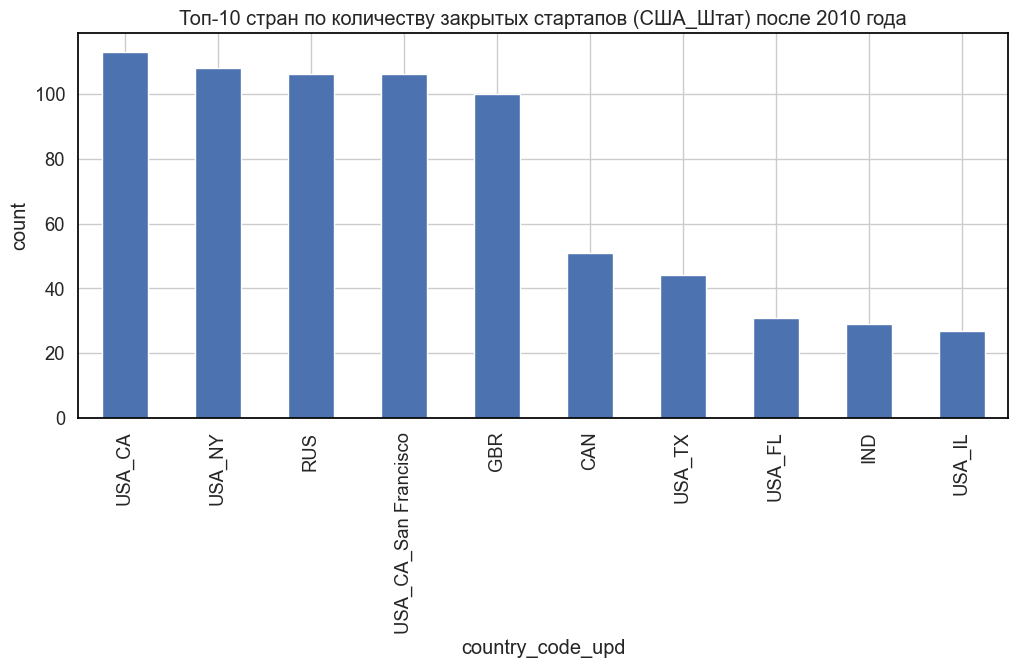

In [74]:
(data_train.query('status=="closed" & founded_at > 2010')['country_code_upd']
 .value_counts()
 .head(10)
 .plot(kind='bar',
       title='Топ-10 стран по количеству закрытых стартапов (США_Штат) после 2010 года',
       ylabel='count',
       figsize=(12,5))
);

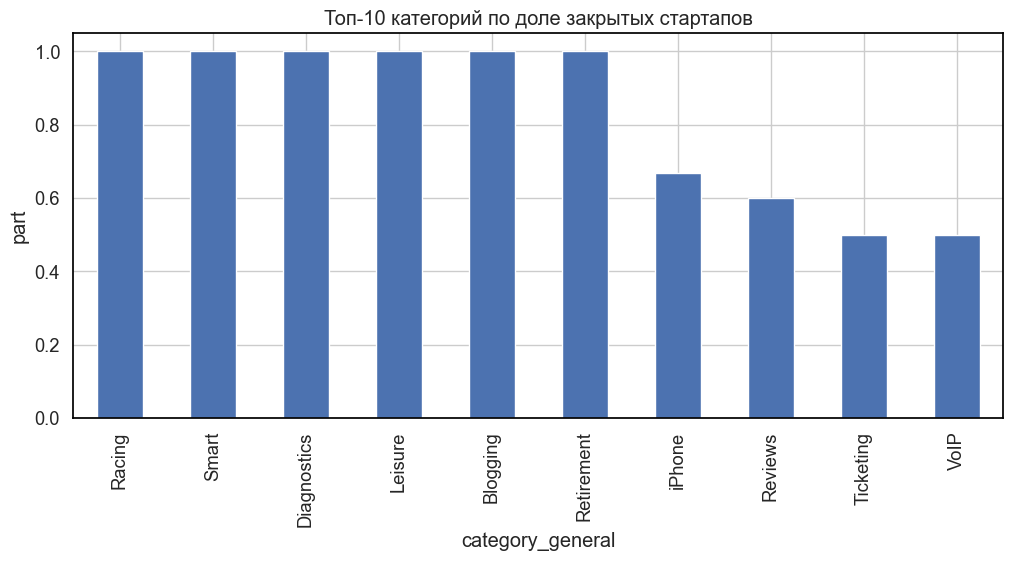

In [75]:
(
    (data_train.query('status=="closed" & founded_at > 2010')['category_general'].value_counts() /
     data_train.query('founded_at > 2010')['category_general'].value_counts())
    .sort_values(ascending=False)
     .head(10)
     .plot(kind='bar',
           title='Топ-10 категорий по доле закрытых стартапов',
           ylabel='part',
           figsize=(12,5))
);

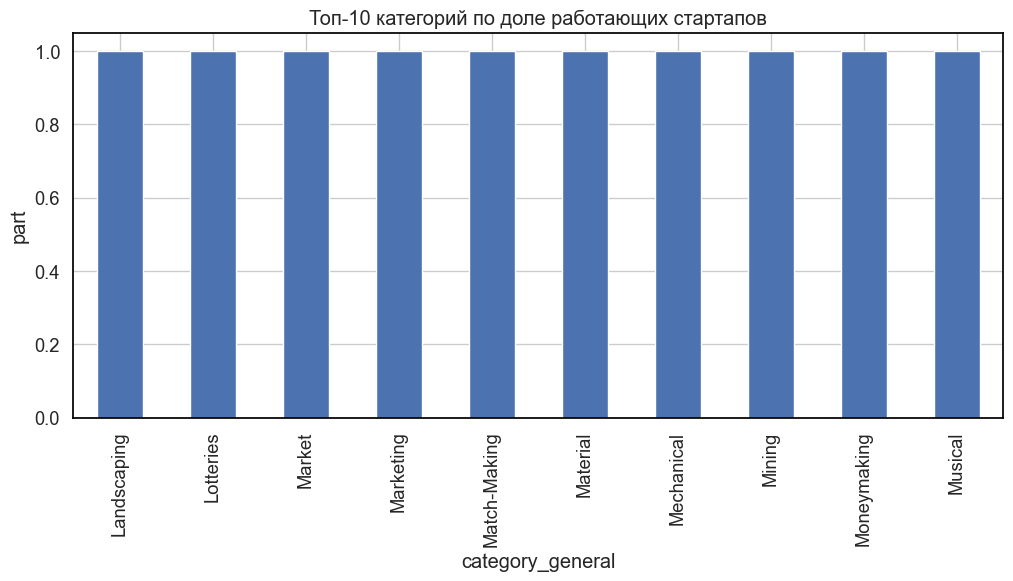

In [76]:
(
    (data_train.query('status=="operating" & founded_at > 2010')['category_general'].value_counts() /
     data_train.query('founded_at > 2010')['category_general'].value_counts())
    .sort_values(ascending=False)
     .head(10)
     .plot(kind='bar',
           title='Топ-10 категорий по доле работающих стартапов',
           ylabel='part',
           figsize=(12,5))
);

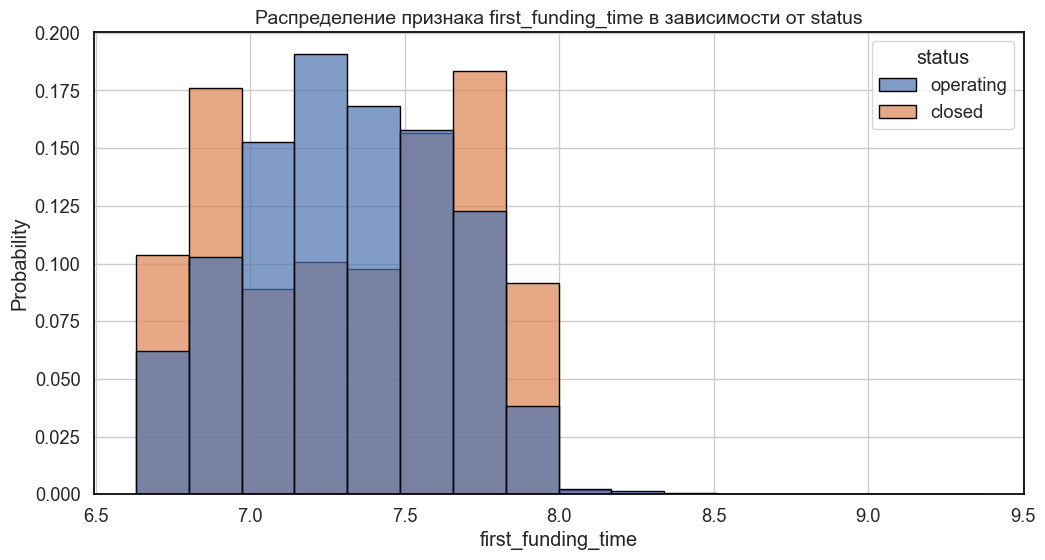

Медианное количество дней после первого финансирования у открытых стартапов -  1492.0
Медианное количество дней после первого финансирования у закрытых стартапов -  1606.0


In [77]:
describe_column(np.log(data_train.query('founded_at > 2010')['first_funding_time']),
                hue=data_train['status'], alpha=0.7)
print('Медианное количество дней после первого финансирования у открытых стартапов - ',
      data_train.query('status=="operating" & founded_at > 2010')['first_funding_time'].median())
print('Медианное количество дней после первого финансирования у закрытых стартапов - ',
      data_train.query('status=="closed" & founded_at > 2010')['first_funding_time'].median())

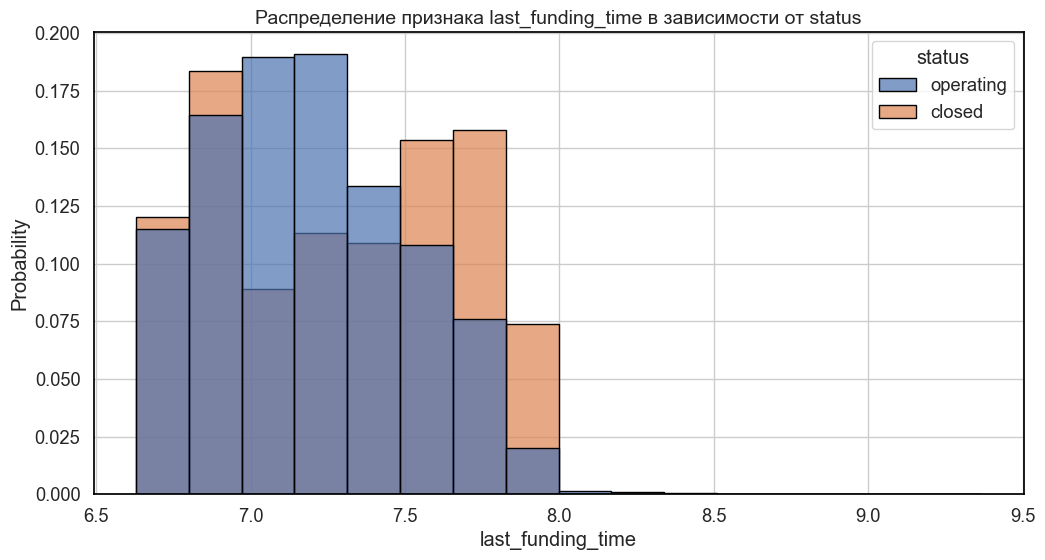

Медианное количество дней после последнего финансирования у открытых стартапов -  1299.0
Медианное количество дней после последнего финансирования у закрытых стартапов -  1492.0


In [78]:
describe_column(np.log(data_train.query('founded_at > 2010')['last_funding_time']),
                hue=data_train['status'], alpha=0.7)
print('Медианное количество дней после последнего финансирования у открытых стартапов - ',
      data_train.query('status=="operating" & founded_at > 2010')['last_funding_time'].median())
print('Медианное количество дней после последнего финансирования у закрытых стартапов - ',
      data_train.query('status=="closed" & founded_at > 2010')['last_funding_time'].median())

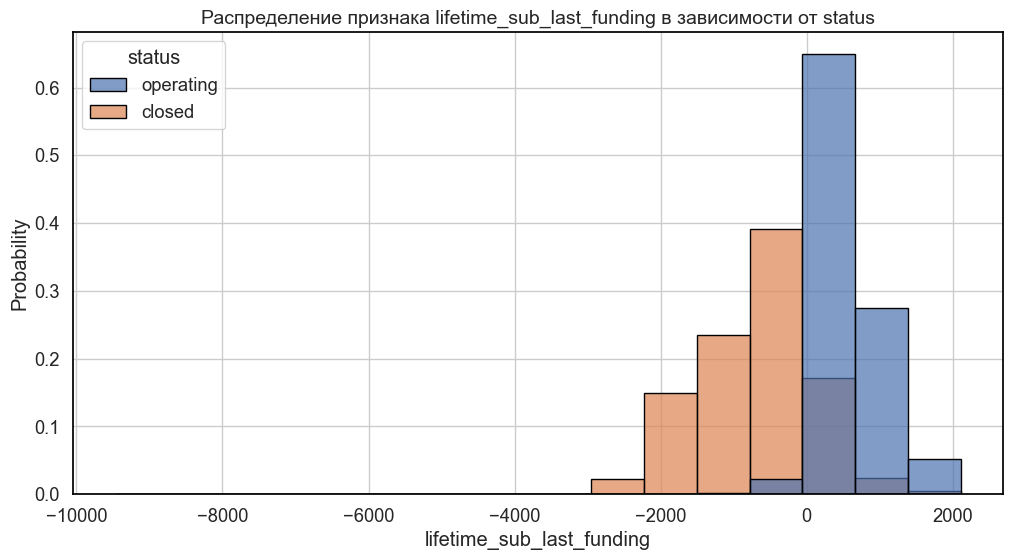

Медианная разница в днях между последним финансированем и временем жизни у открытых стартапов -  484.0
Медианная разница в днях между последним финансированем и временем жизни у закрытых стартапов -  -574.0


In [79]:
describe_column(data_train.query('founded_at > 2010')['lifetime_sub_last_funding'],
                hue=data_train['status'], alpha=0.7)
print('Медианная разница в днях между последним финансированем и временем жизни у открытых стартапов - ',
      data_train.query('status=="operating" & founded_at > 2010')['lifetime_sub_last_funding'].median())
print('Медианная разница в днях между последним финансированем и временем жизни у закрытых стартапов - ',
      data_train.query('status=="closed" & founded_at > 2010')['lifetime_sub_last_funding'].median())

### Вывод

- **Медианный портрет закрывшегося стартапа**
    - Медианный объем инвестиций - 1.3 млн USD
    - Медианное время жизни -  1013 дней
    - Стартап с одним раундом инвестиций стартап вероятнее закрыт
    - Находится в США - Калифорния - Сан-Франциско
    - Вероятнее всего из областей `iPhone`, `Television`, `Reviews`
    - Был создан до 2012 года
    - Медианное количество дней после первого финансирования -  2701
    - Медианное количество дней после последнего финансирования -  2467
    - Медианная разница в днях между последним финансированем и временем жизни - -1231                                            
    

- **Медианный портрет работающего стартапа**
    - Медианный объем инвестиций - 2.0 млн USD
    - Медианное время жизни -  2579 дней
    - Больше 1 раунда инвестиций
    - Находится в США - Калифорния - Сан-Франциско
    - Вероятнее всего из областей `IT`, `FinTech`, `Data`
    - Открыт после 2013 года и до 2016 года
    - Медианное количество дней после первого финансирования -  1933
    - Медианное количество дней после последнего финансирования -  1538
    - Медианная разница в днях между последним финансированем и временем жизни - 706
    
    
- **Общие выводы**
    - Сильный дисбаланс между классами - 9 к 1 в пользу работающих
    - `funding_total_usd`
        - Распределение похоже на логнормальное
        - Есть статистически значимое различие в признаке в зависимости от статуса стартапа
        - Добавили `funding_total_usd_log`
    - `lifetime`
        - Распределение признака похоже на логнормальное
        - Есть статистически значимое различие в признаке в зависимости от статуса стартапа
        - Добавили `lifetime_log`
    - `country_code_upd`
        - Заменили все 4 географических признака на `country_code_upd`, где данные рапспределены более равномерно
        - Больше всего стартапов в США - около 30 000
        - Около 10 000 приходится на Калифорнию
        - Около 7 000 приходится на залив Сан-Франциско
    - `category_list`
        - Добавили признак `category_general` из топ-100 категорий
    - `funding_time`
        - Добавили новые признаки `first_funding_time`, `last_funding_time` и `between_funding_time`, `last_funding_year` и `lifetime_sub_last_funding`
        
        
- **Ситауция после 2010 года**
    - **Медианный портрет закрывшегося стартапа**
        - Медианный объем инвестиций - 760 тыс USD
        - Медианное время жизни -  846 дней
        - Стартап с одним раундом инвестиций стартап вероятнее закрыт
        - Находится в США - Калифорния - Сан-Франциско, так же **Россия - топ-3, видимо из-за санкций после 2014**
        - Вероятнее всего из областей `iPhone`, `Reviews`, `Application` - **мобильные разработки**
        - Медианное количество дней после первого финансирования -  1606
        - Медианное количество дней после последнего финансирования -  1492
        - Медианная разница в днях между последним финансированем и временем жизни - -574

    - **Медианный портрет работающего стартапа**
        - Медианный объем инвестиций - 285 тыс USD
        - Медианное время жизни -  1909 дней
        - Больше 1 раунда инвестиций
        - Находится в США - Калифорния - Сан-Франциско
        - Вероятнее всего из областей `IT`, `Payments`, `Marketing` - **ИТ в платежах и маркетинге**
        - Медианное количество дней после первого финансирования -  1492
        - Медианное количество дней после последнего финансирования -  1299
        - Медианная разница в днях между последним финансированем и временем жизни -  484

## Подбор модели прогнозирования статуса стартапа

### Корреляционный анализ

In [80]:
interval_cols = [
    'funding_total_usd_log',
    'lifetime_log',
    'first_funding_time_log',
    'last_funding_time_log',
    'lifetime_sub_last_funding',
    'lifetime_sub_first_funding',
    'category_closed_part'
]

cols_for_model = interval_cols + [
    'status',
    'funding_rounds',
    'category_1',
    'category_2',
    'category_3',
    'category_4',
    'category_5',
    'category_general',
    'country_code_upd',
    'last_funding_year'
]

data = data_train[cols_for_model].copy()
corr_matrix_1 = data.dropna().phik_matrix(interval_cols=interval_cols)

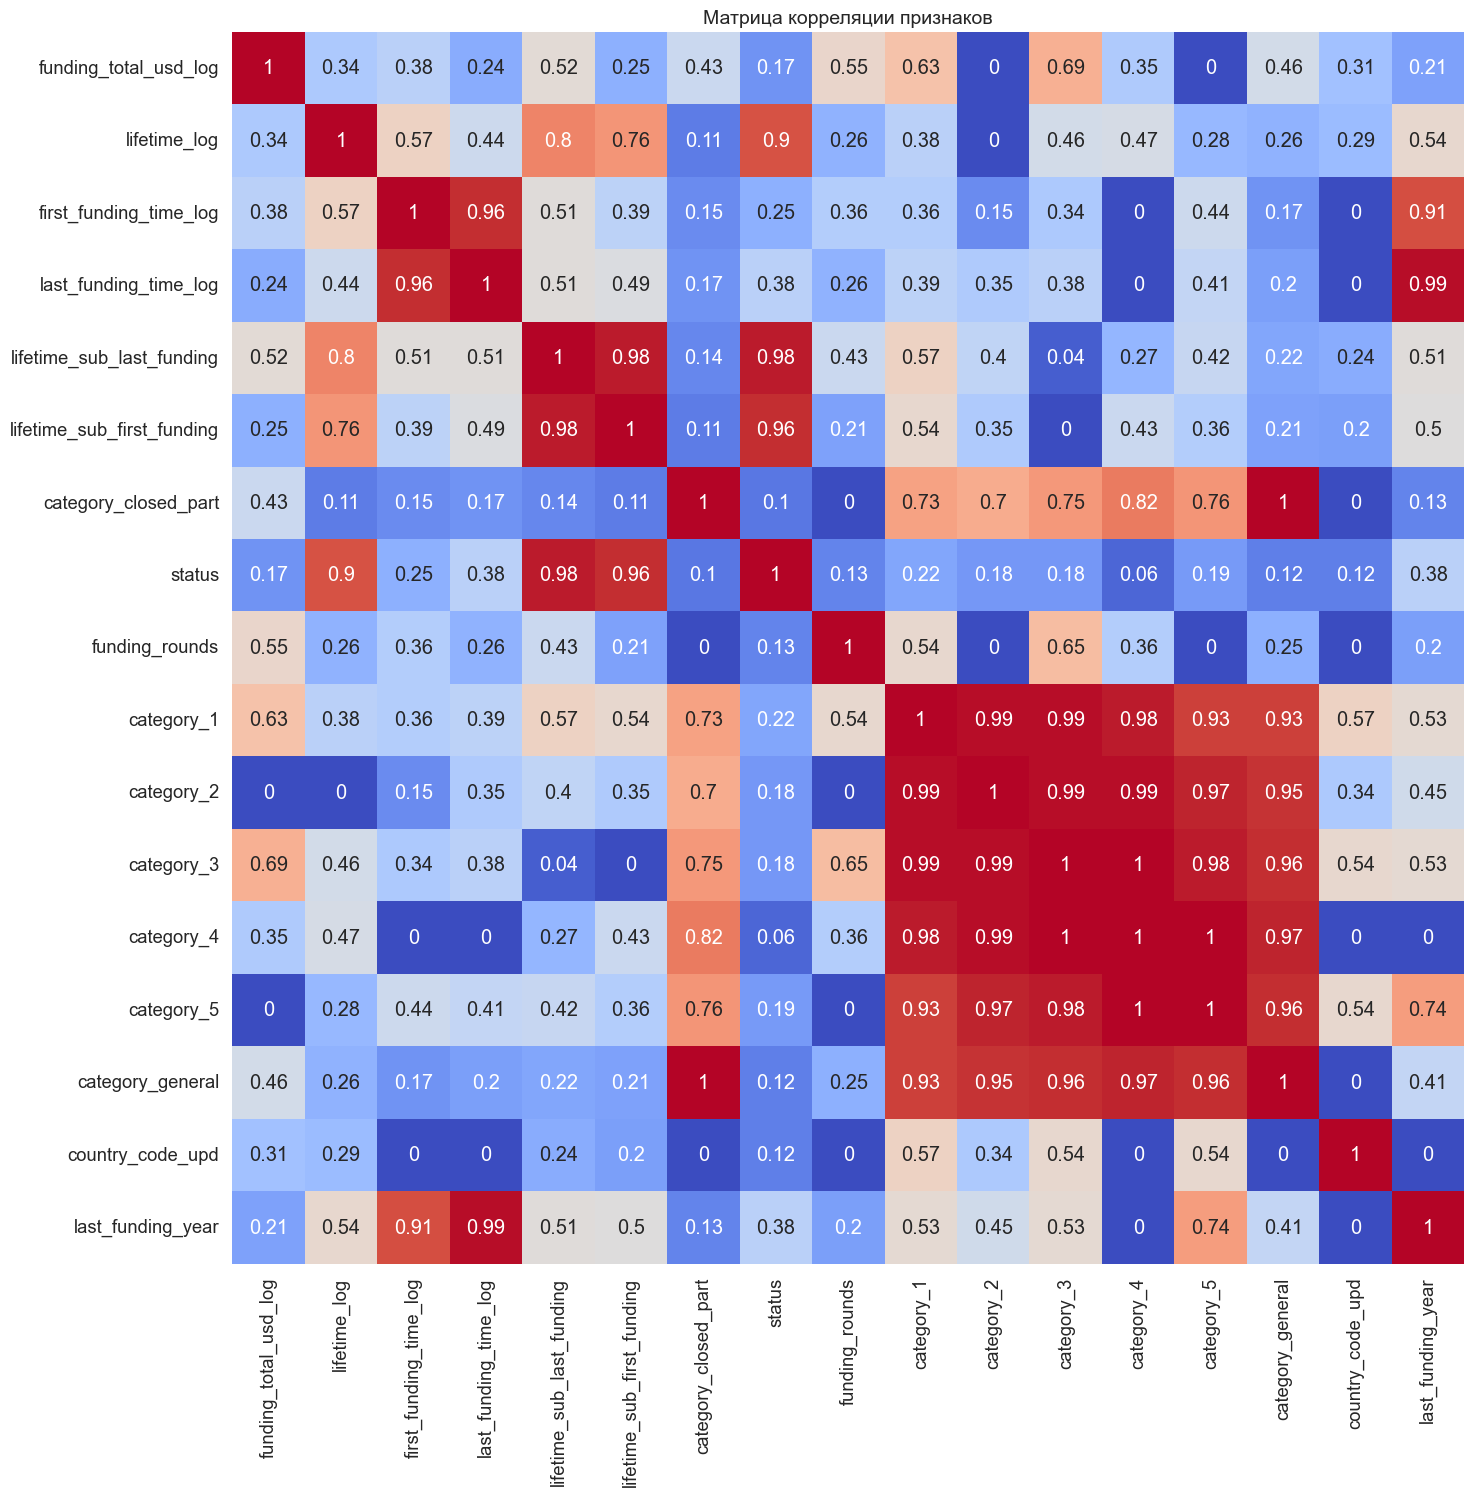

In [81]:
plt.figure(figsize=(16, 16))
plt.title('Матрица корреляции признаков',
          fontsize=14)
sns.heatmap(corr_matrix_1.round(2),
            annot = True, square=True,
            cmap='coolwarm',
            cbar=False);

In [82]:
cols_= [
    'const',
    'funding_total_usd_log',
    'lifetime_log',
    'last_funding_time_log',
    'first_funding_time_log',
    'lifetime_sub_last_funding',
    'lifetime_sub_first_funding',
    'last_funding_year',
    'funding_rounds',
    'category_closed_part'
]

df_ = add_constant(data.copy().reset_index())
df_.dropna(inplace=True)

vif_data = pd.DataFrame()
vif_data['feature'] = df_[cols_].columns
vif_data['VIF'] = [variance_inflation_factor(df_[cols_].values, i)
                          for i in range(len(df_[cols_].columns))]
vif_data

,feature,VIF
0,const,6.858361e+06
1,funding_total_usd_log,1.778094e+00
2,lifetime_log,6.043313e+00
3,last_funding_time_log,1.925893e+01
4,first_funding_time_log,2.299443e+01
5,lifetime_sub_last_funding,4.479834e+01
6,lifetime_sub_first_funding,3.402073e+01
7,last_funding_year,9.944608e+00
8,funding_rounds,2.682354e+00
9,category_closed_part,1.035407e+00


- Есть сильная взаимная корреляция между новыми входными признаками. В контексте категорий стартапов много повторяющихся значений вроде `Software` или `Other`. В контексте времени жизни стартапа и времени инвестиций - считали от 2018 года, то есть корреляция есть, но в ней скрыта дата инвестиций и влияние этого периода времени. Кроме того, они все входят под логарифмами
- С целевым признаком сильнее всего коррелирует `lifetime_sub_last_funding` - 0.98, `lifetime_sub_first_funding` - 0.96, `lifetime_log` - 0.9
- Признаки, связанные со временем инвестиций, коррелируют на уровне 0.25 с целевым признаком
- Признаки категории стартапов коррелируют на уровне 0.15 с целевым признаком
- По VIF анализу все численные признаки меньше 10, кроме признаков, связанных со временем инвестиций, там они на уровне 20-40, неприятно, но ожидаемо, паттерны у объектов в целом похожие, но у нас сильный дисбаланс, и кроме того используем для некоторых логарифм значения, на построении модели будем аккуратны с ними

### Поиск модели

Для соревнования будем использовать весь датасет для обучения. В исследовании поделим на тестовую и валидационные выборки

In [83]:
X = data.drop('status', axis=1)
y = data['status']

cat_cols = [
    'category_1',
    'category_2',
    'category_3',
    'category_4',
    'category_5',
    'category_general',
    'country_code_upd'
]

num_cols = [
    'funding_total_usd_log',
    'funding_rounds',
    'lifetime_log',
    'last_funding_time_log',
    'first_funding_time_log',
    'lifetime_sub_last_funding',
    'last_funding_year',
    'category_closed_part',
    'lifetime_sub_first_funding'
]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)


# кодируем целевую переменную
original_classes = ['operating', 'closed']
label_encoder = LabelEncoder()
label_encoder.fit_transform(np.array(original_classes))
label_encoder.classes_ = np.array(original_classes)
y_train = label_encoder.transform(y_train)
y_valid = label_encoder.transform(y_valid)
y = label_encoder.transform(y)
pd.DataFrame(list(range(len(label_encoder.classes_))),
             label_encoder.classes_, columns=['LabelEncoder'])

,LabelEncoder
operating,0
closed,1


Для начала попробуем быстро прогнать через GridSearchCV три модели LogisticRegression, LightGBM и CatBoost

In [84]:
# cat_pipeline
cat_pipe = Pipeline(
    [
        (
            'imputer_before',
            SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Unknown')
        ),

        (
            'ordinal_encoder',
             OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)
        ),

        (
            'imputer_after',
             SimpleImputer(missing_values=np.nan, strategy='constant', fill_value=-1)
        )
    ])

# num_pipeline
num_pipe = Pipeline(
    [
        (
            'imputer',
            SimpleImputer(strategy='constant', fill_value=0)
        ),

        ('scaler', 'passthrough')
    ])

# Preprocessor = CAT + NUM
preprocessor = ColumnTransformer(
    [
        ('cat', cat_pipe, cat_cols),
        ('num', num_pipe, num_cols)
    ])

# Preprocessor + Models
pipe_search = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('models', LogisticRegression())
    ])

In [85]:
param_search = [
            {'models': [LogisticRegression()],
             'models__C': [0.1,1,10],
             'models__random_state': [RANDOM_STATE],
             'models__max_iter' : [3000],
             'preprocessor__num__scaler': [StandardScaler(), RobustScaler()]},

            {'models' : [LGBMClassifier()],
             'models__random_state': [RANDOM_STATE],
             'models__colsample_bytree': [0.5],
             'models__max_depth': [6],
             'models__n_estimators': [100],
             'models__learning_rate': [0.1],
             'models__verbose': [-1]},

            {'models': [CatBoostClassifier()],
             'models__random_state' : [RANDOM_STATE],
             'models__silent': [True],
             'models__iterations': [100],
             'models__depth': [6],
             'models__l2_leaf_reg': [1],
             'models__learning_rate': [0.1]}
]

In [86]:
%%time
model_search = GridSearchCV(
    pipe_search,
    param_search,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

model_search.fit(X_train, y_train)
print(f'Лучшая модель: {model_search.best_estimator_.named_steps["models"]}')
print(f'Метрика f1 лучшей модели по результатам кросс-валидации: {round(model_search.best_score_, 3)}')

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Лучшая модель: LGBMClassifier(colsample_bytree=0.5, max_depth=6, random_state=42, verbose=-1)
Метрика f1 лучшей модели по результатам кросс-валидации: 0.882
Wall time: 44.6 s


Ожидаемо, что кто-то из градиентных бустингов показал лучший результат, но посмотрим подробнее

In [87]:
def search_cv_results(search):
    df = pd.concat([pd.DataFrame(search.cv_results_['params']),
                    pd.DataFrame(search.cv_results_['mean_test_score'],
                                 columns=['Score'])], axis=1)
    df = df.sort_values('Score', ascending=False)
    return df.fillna(value='')

In [88]:
df_res = search_cv_results(model_search)
df_res.head(3)

,models,models__C,models__max_iter,models__random_state,preprocessor__num__scaler,models__colsample_bytree,models__learning_rate,models__max_depth,models__n_estimators,models__verbose,models__depth,models__iterations,models__l2_leaf_reg,models__silent,Score
6,LGBMClassifier(),,,42,,0.5,0.1,6.0,100.0,-1.0,,,,,0.882404
7,<catboost.core.CatBoostClassifier object at 0x...,,,42,,,0.1,,,,6.0,100.0,1.0,True,0.881540
4,LogisticRegression(),10.0,3000.0,42,StandardScaler(),,,,,,,,,,0.840463


- Сразу можно отметить, что LogisticRegression отстает, но не так сильно, как можно было предположить, с F1 около 0.84 против 0.88 у других
- LightGBM и CatBoost показывают почти одинаковый результат, но LightGBM быстрее, поэтому продолжим работать с ним, так как в CatBoost лучше отдавать категориальные признаки без кодирования, что заметно повышает время оптимизации
- Для точного результата воспользуемся GridSearchCV, время на Ryzen 4 занимает 2.5 минуты, в отличие от 25 минут для CatBoost, а с RanomizedSearchCV чуть меньше, но и для соревнования будет долговато
- Optuna тоже показывает около получаса для CatBoost, результат при этом хуже, чем у LightGBM

In [89]:
cv_outer=StratifiedKFold(n_splits=4, random_state=RANDOM_STATE, shuffle=True)
params = [
            {'models' : [LGBMClassifier()],
             'models__random_state': [RANDOM_STATE],
             'models__colsample_bytree': [0.5],
             'models__reg_lambda' : [0.1, 1, 2, 10],
             'models__max_depth': np.arange(5, 9, 1),
             'models__n_estimators': np.arange(100, 400, 100),
             'models__learning_rate': [0.07, 0.1, 0.2],
             'models__verbose': [-1]
            }]

In [90]:
%%time

model = GridSearchCV(
    pipe_search,
    params,
    cv=cv_outer,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

model.fit(X_train, y_train)
print(f'Лучшая модель: {model.best_estimator_.named_steps["models"]}')
print(f'Метрика f1 лучшей модели по результатам кросс-валидации: {round(model.best_score_, 3)}')

Fitting 4 folds for each of 144 candidates, totalling 576 fits
Лучшая модель: LGBMClassifier(colsample_bytree=0.5, learning_rate=0.2, max_depth=6,
               n_estimators=200, random_state=42, reg_lambda=10, verbose=-1)
Метрика f1 лучшей модели по результатам кросс-валидации: 0.889
Wall time: 3min 8s


In [91]:
best_model = model.best_estimator_
best_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer_before',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('ordinal_encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=nan)),
                                                                  ('imputer_after',
                                                                   SimpleImputer(fill_value=-1,
                                                                                 strategy='constant'))]),
                                                  ['category_1', 'category_2',
                                                   'ca...
                                                                   'passthrough')]),
                                                  ['funding_total_usd_log',
                                                   'funding_rounds',
                                                   'lifetime_log',
                                                   'last_funding_time_log',
                                                   'first_funding_time_log',
                                                   'lifetime_sub_last_funding',
                                                   'last_funding_year',
                                                   'category_closed_part',
                                                   'lifetime_sub_first_funding'])])),
                ('models',
                 LGBMClassifier(colsample_bytree=0.5, learning_rate=0.2,
                                max_depth=6, n_estimators=200, random_state=42,
                                reg_lambda=10, verbose=-1))])

In [92]:
df_res = search_cv_results(model)
df_res.head(5)

,models,models__colsample_bytree,models__learning_rate,models__max_depth,models__n_estimators,models__random_state,models__reg_lambda,models__verbose,Score
115,LGBMClassifier(),0.5,0.20,6,200,42,10.0,-1,0.888861
95,LGBMClassifier(),0.5,0.10,8,300,42,10.0,-1,0.888583
46,LGBMClassifier(),0.5,0.07,8,300,42,2.0,-1,0.888196
106,LGBMClassifier(),0.5,0.20,5,300,42,2.0,-1,0.888156
119,LGBMClassifier(),0.5,0.20,6,300,42,10.0,-1,0.888155


### Анализ важности признаков

In [93]:
cols_for_model.remove('status')

100%|===================| 19686/19694 [01:30<00:00]        

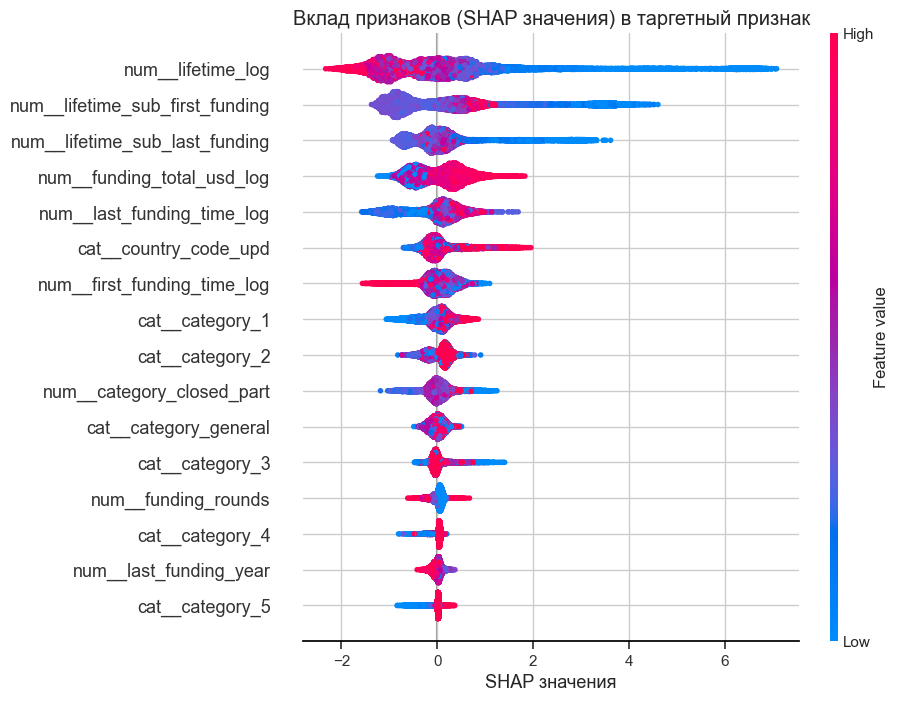

In [94]:
X_train_encoded = best_model['preprocessor'].transform(
    X_train[cols_for_model].sample(random_state=RANDOM_STATE, frac=0.5))
feature_names = (
    best_model['preprocessor']
    .get_feature_names_out()
)

explainer = shap.TreeExplainer(
    best_model['models'],
    X_train_encoded,
    feature_names=feature_names
)

shap_values = explainer(X_train_encoded, check_additivity=False)
shap.plots.beeswarm(shap_values, max_display=19, show=False)
plt.title('Вклад признаков (SHAP значения) в таргетный признак')
plt.xlabel('SHAP значения');

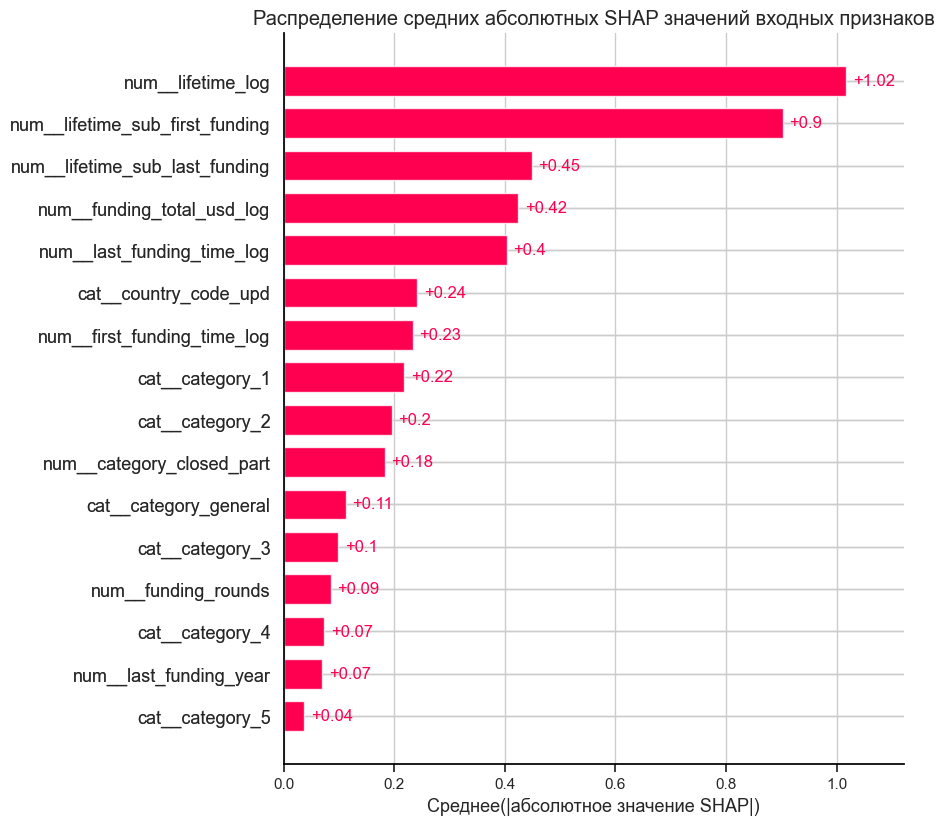

In [95]:
shap.plots.bar(shap_values, max_display=19, show=False)
plt.title('Распределение средних абсолютных SHAP значений входных признаков')
plt.xlabel('Среднее(|абсолютное значение SHAP|)');

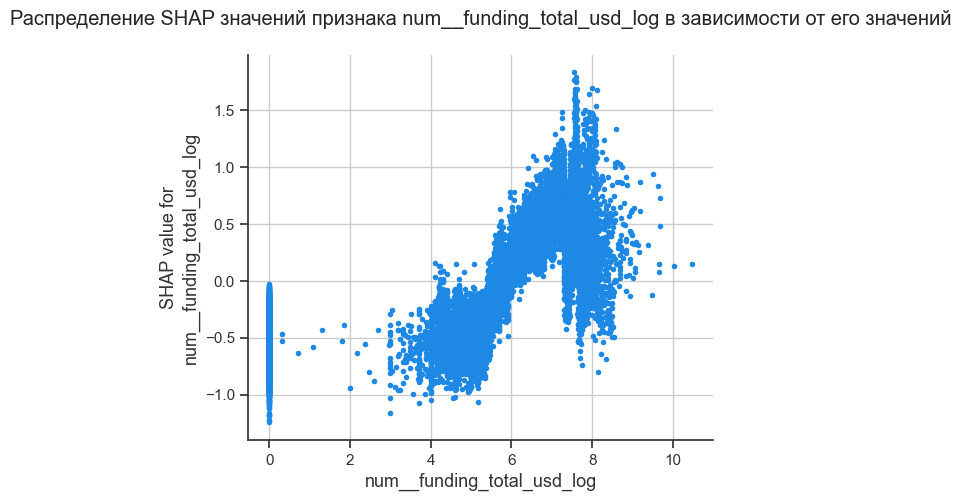

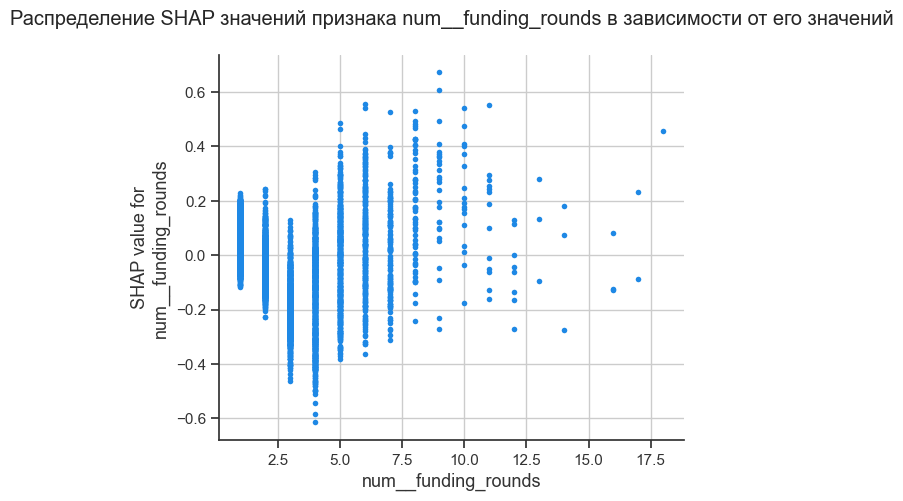

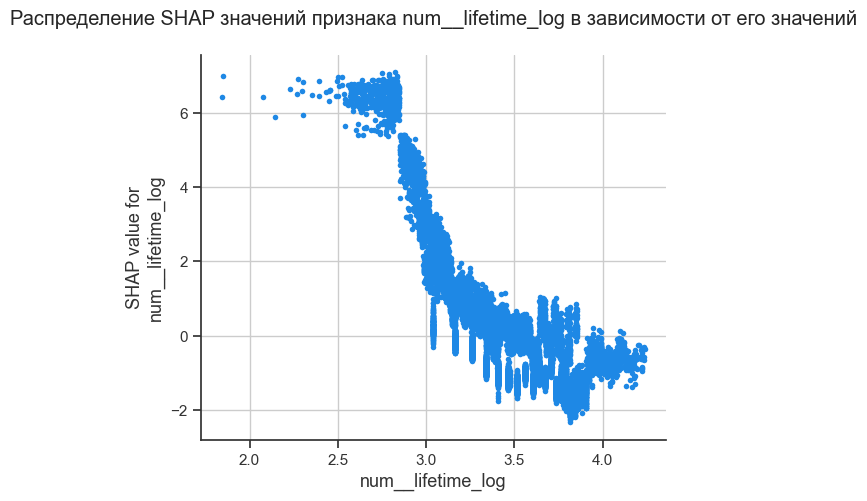

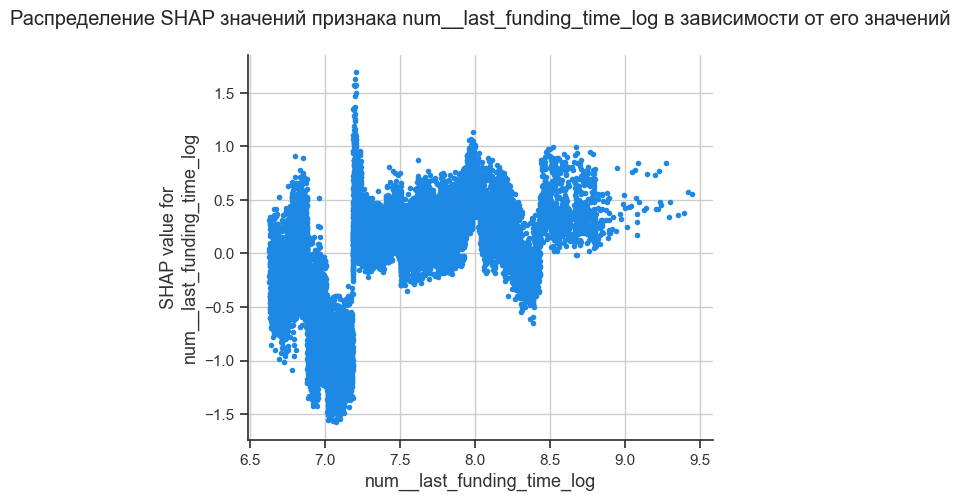

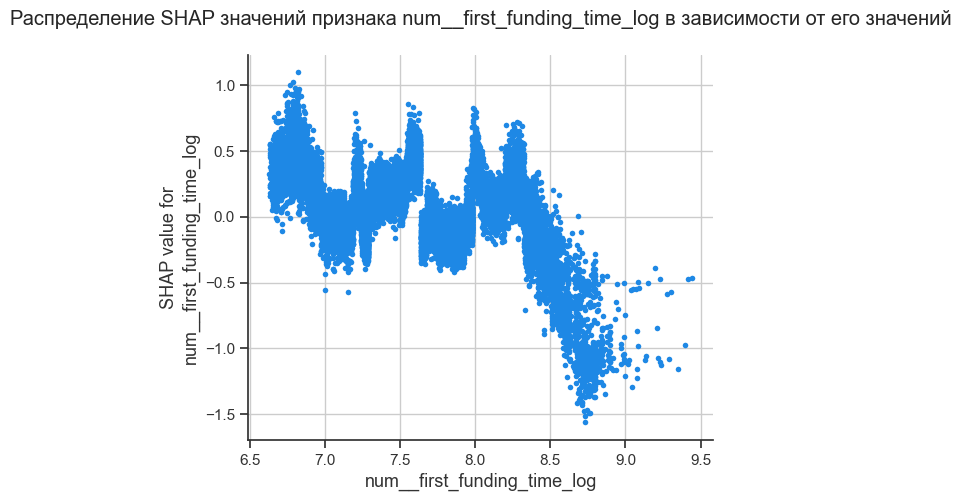

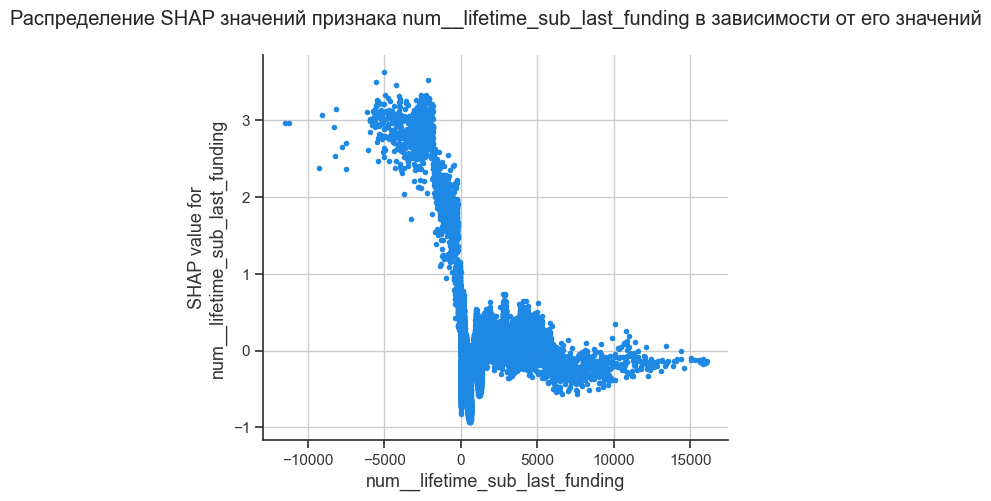

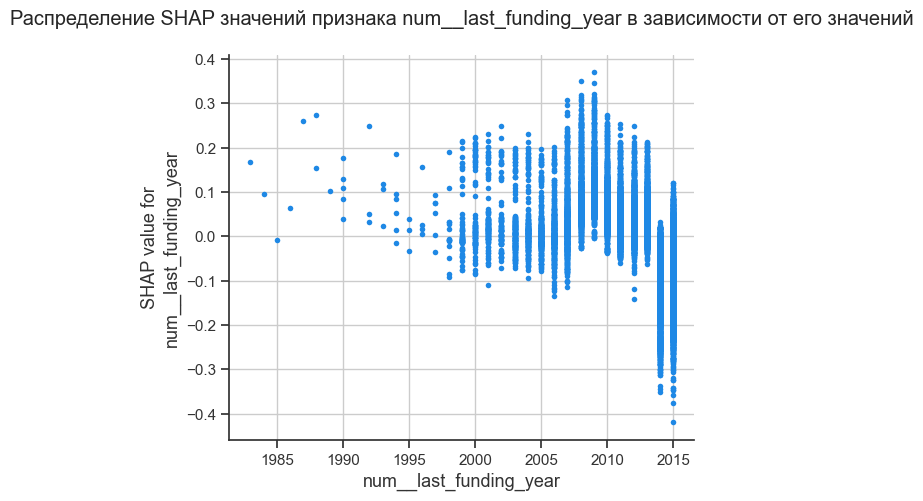

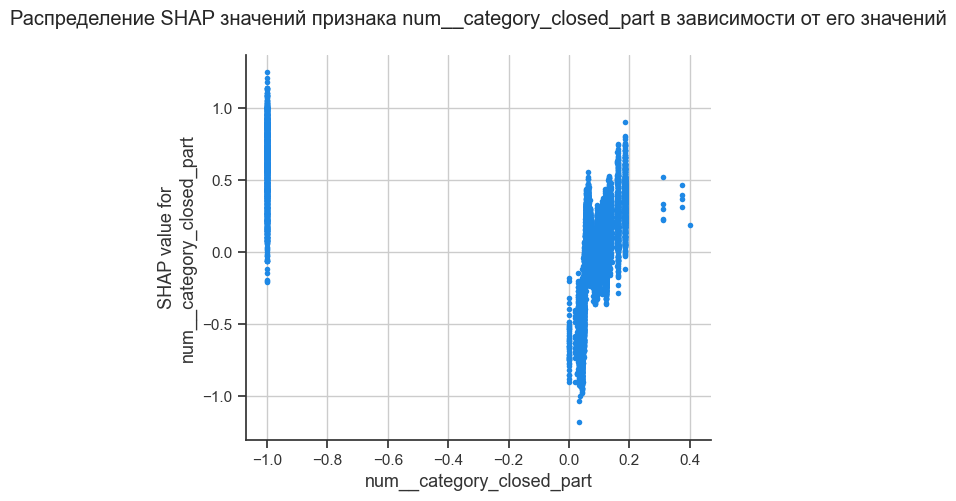

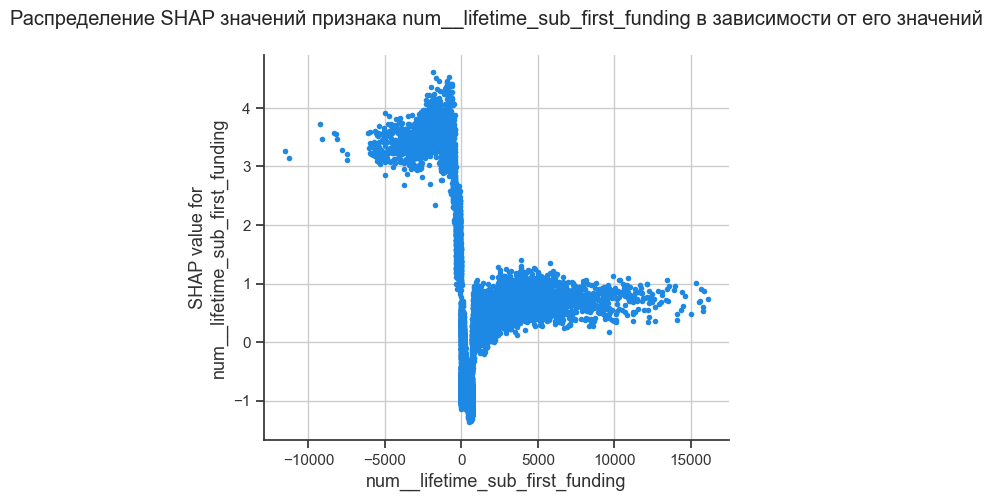

In [96]:
for i in range(len(feature_names)):
    if i > len(cat_cols)-1:
        shap.dependence_plot(
            i,
            shap_values.values,
            X_train_encoded,
            feature_names=feature_names,
            show=False,
            interaction_index=None
            )
        plt.title(f'Распределение SHAP значений признака {feature_names[i]} в зависимости от его значений\n')

- Сильнее всего влияет время жизни стартапа - около 1.5 тыс дней и стартап вероятнее всего будет все еще работать
- Чем ближе к 0 доля закрытых стартапов в общей категории, тем выше вероятность, что он работает, при приближении доли к ~0.25 растет вероятность его закрытия, само собой лучше занимать не трендовые ниши
- Можно обратить внимание на области стартапов закрывшихся в 2008-2010 годах, тогда многие закрывались по финансовым причинам
- Важно постараться пройти дальше второго раунда инвестиций, там вероятность не закрыться возрастает
- Так же задерживаться долго в раундах инвестиций не стоит, вероятность закрытия после 5 раунда возвращается обратно к первым раундам
- Также лучше постараться перешагнуть 1 млн USD инвестиций

### Калибровка модели

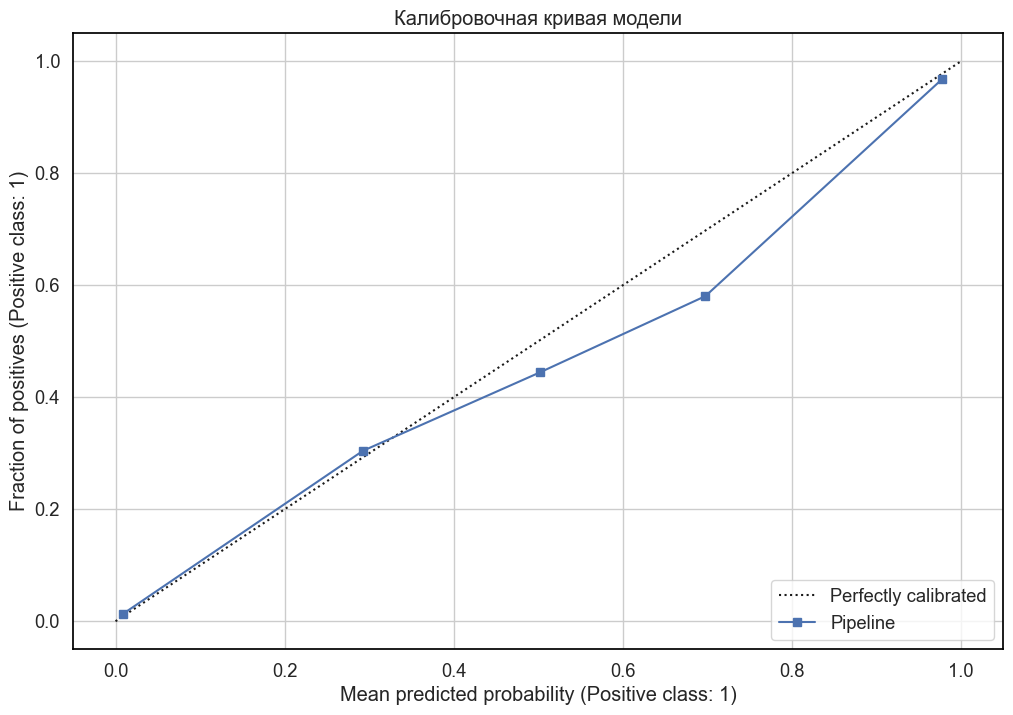

In [97]:
disp = CalibrationDisplay.from_estimator(best_model, X_valid, y_valid)
disp.figure_.set_size_inches(12, 8)
plt.title('Калибровочная кривая модели');

In [98]:
best_model_cal = (
    CalibratedClassifierCV(best_model, cv=5, method='isotonic')
    .fit(X_train, y_train)
)
y_pred = best_model_cal.predict(X_valid)
y_proba = best_model_cal.predict_proba(X_valid)[:,1]

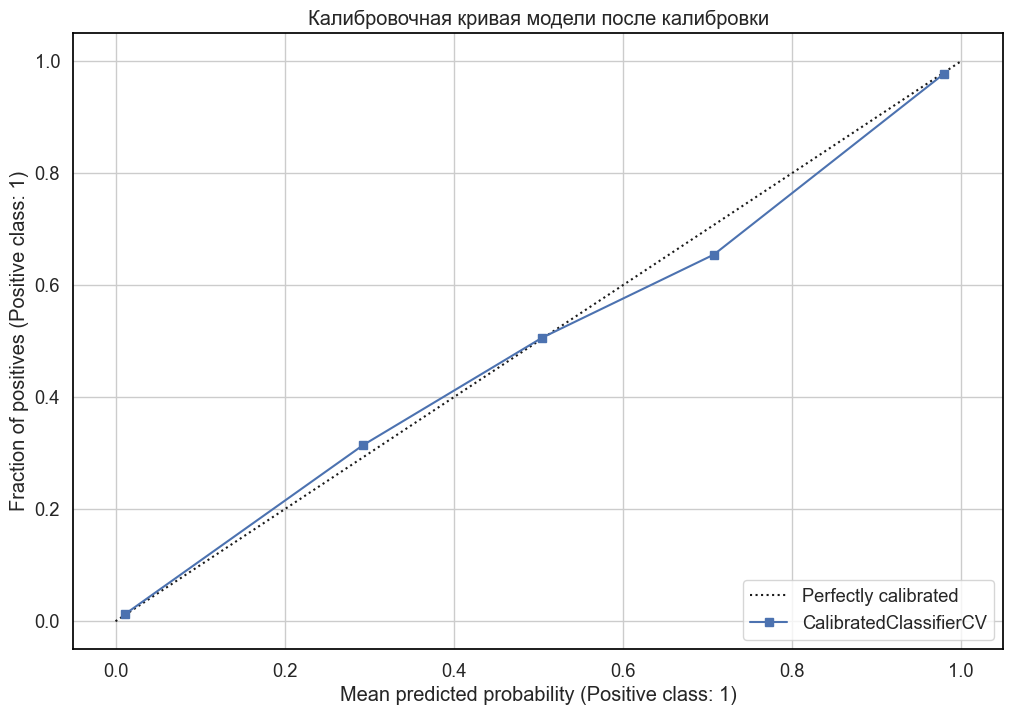

In [99]:
disp = CalibrationDisplay.from_estimator(best_model_cal, X_valid, y_valid)
disp.figure_.set_size_inches(12, 8)
plt.title('Калибровочная кривая модели после калибровки');

Откалибровали модель, чтобы она предсказывала вероятности классов. Просадка после вероятности 0.5 стала меньше

### Метрики модели

In [100]:
# Создадим функцию для вывода метрики модели
# Принимает на вход y_test - тестовая выборка, predictions - предсказание целевого признака
def model_metrics(y_test, predictions, probabilities, name):
    print(f'F1 score - {round(f1_score(y_test, predictions), 3)}')
    print(f'Recall - {round(recall_score(y_test, predictions), 3)}')
    print(f'Precision - {round(precision_score(y_test, predictions), 3)}')
    cm = confusion_matrix(y_test, predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r')
    plt.title(f'Матрица ошибок {name}')
    plt.xlabel('Предсказанный класс')
    plt.ylabel('Истинный класс')

F1 score - 0.88
Recall - 0.829
Precision - 0.937


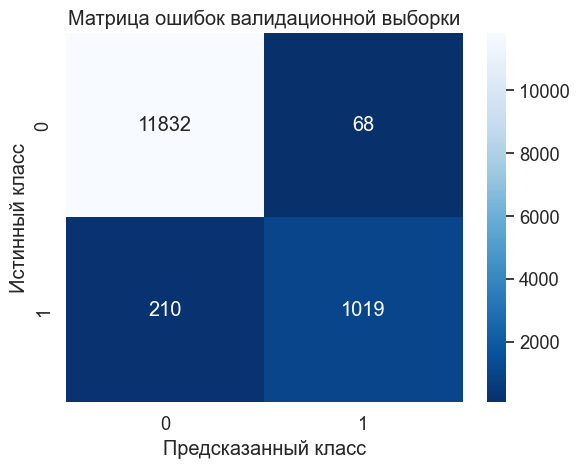

In [101]:
model_metrics(y_valid,
                 best_model_cal.predict(X_valid),
                 best_model_cal.predict_proba(X_valid)[:,1],
                 'валидационной выборки')

- F1-score немного просел на валидационной выборке - 0.889 -> 0.880
- Precision - 0.937
- Recall - 0.829

Посмотрим какой результат выдает dummy регрессионная модель

F1 score - 0.0
Recall - 0.0
Precision - 0.0


Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.


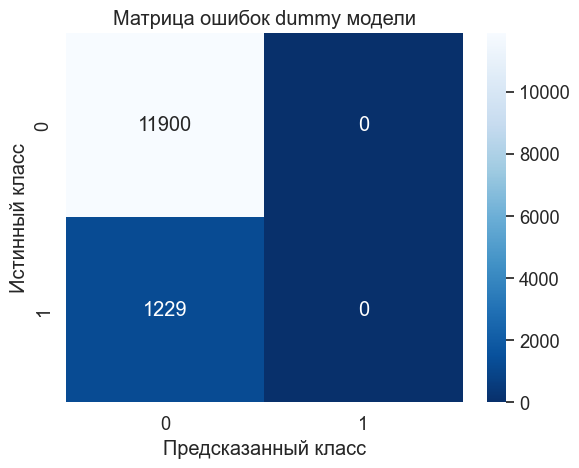

In [120]:
dummy_class = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy_class.fit(X_train, y_train)
y_dummy_predict = dummy_class.predict(X_valid)
y_dummy_proba = dummy_class.predict_proba(X_valid)[:,1]
model_metrics(y_valid, y_dummy_predict, y_dummy_proba, 'dummy модели')

Наша модель показывает явно лучший результат

### Модель для соревнования

Найдем лучшую модель на полных тренировочных данных для соревнования и выгрузим результат

In [103]:
%%time

cv_outer=StratifiedKFold(n_splits=3, random_state=RANDOM_STATE, shuffle=True)

kaggle_search = GridSearchCV(
    pipe_search,
    params,
    cv=cv_outer,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

kaggle_search.fit(X, y)
print(f'Лучшая модель: {kaggle_search.best_estimator_.named_steps["models"]}')
print(f'Метрика f1 лучшей модели по результатам кросс-валидации: {round(kaggle_search.best_score_, 3)}')

Fitting 3 folds for each of 144 candidates, totalling 432 fits
Лучшая модель: LGBMClassifier(colsample_bytree=0.5, max_depth=7, n_estimators=200,
               random_state=42, reg_lambda=1, verbose=-1)
Метрика f1 лучшей модели по результатам кросс-валидации: 0.887
Wall time: 2min 45s


In [104]:
model_kaggle = kaggle_search.best_estimator_
model_kaggle

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer_before',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('ordinal_encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=nan)),
                                                                  ('imputer_after',
                                                                   SimpleImputer(fill_value=-1,
                                                                                 strategy='constant'))]),
                                                  ['category_1', 'category_2',
                                                   'ca...
                                                                  ('scaler',
                                                                   'passthrough')]),
                                                  ['funding_total_usd_log',
                                                   'funding_rounds',
                                                   'lifetime_log',
                                                   'last_funding_time_log',
                                                   'first_funding_time_log',
                                                   'lifetime_sub_last_funding',
                                                   'last_funding_year',
                                                   'category_closed_part',
                                                   'lifetime_sub_first_funding'])])),
                ('models',
                 LGBMClassifier(colsample_bytree=0.5, max_depth=7,
                                n_estimators=200, random_state=42, reg_lambda=1,
                                verbose=-1))])

Неплохо, лучшая метрика не с крайними значениями гиперпараметров

In [105]:
df_res = search_cv_results(kaggle_search)
df_res.head(5)

,models,models__colsample_bytree,models__learning_rate,models__max_depth,models__n_estimators,models__random_state,models__reg_lambda,models__verbose,Score
77,LGBMClassifier(),0.5,0.10,7,200,42,1.0,-1,0.887003
58,LGBMClassifier(),0.5,0.10,5,300,42,2.0,-1,0.886966
71,LGBMClassifier(),0.5,0.10,6,300,42,10.0,-1,0.886942
33,LGBMClassifier(),0.5,0.07,7,300,42,1.0,-1,0.886893
120,LGBMClassifier(),0.5,0.20,7,100,42,0.1,-1,0.886742


Выгрузим прдесказание на тестовой выборке для соревнования

In [106]:
y_pred = model_kaggle.predict(data_test[cols_for_model])
data_test['status'] = pd.DataFrame(y_pred)
data_test['status'] = data_test['status'].apply(lambda x: 'closed' if x == 1 else 'operating')
competition = data_test [['name', 'status']]
#competition.to_csv(r'submit.csv', index=False)

In [107]:
model_kaggle

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer_before',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('ordinal_encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=nan)),
                                                                  ('imputer_after',
                                                                   SimpleImputer(fill_value=-1,
                                                                                 strategy='constant'))]),
                                                  ['category_1', 'category_2',
                                                   'ca...
                                                                  ('scaler',
                                                                   'passthrough')]),
                                                  ['funding_total_usd_log',
                                                   'funding_rounds',
                                                   'lifetime_log',
                                                   'last_funding_time_log',
                                                   'first_funding_time_log',
                                                   'lifetime_sub_last_funding',
                                                   'last_funding_year',
                                                   'category_closed_part',
                                                   'lifetime_sub_first_funding'])])),
                ('models',
                 LGBMClassifier(colsample_bytree=0.5, max_depth=7,
                                n_estimators=200, random_state=42, reg_lambda=1,
                                verbose=-1))])

### Вывод

С помощью первичного поиска GridSearchCV из трех моделей - LogisticRegression, LightGBM и CatBoost определили лучшего кандидата на дальнейший подбор гиперпараметров - LightGBM. У него были близкие резльутаты с CatBoost - около 0.88, но более быстрое время обучения. LogisticRegression показал резльутат около 0.8. Далее полным перебором гиперпараметров была выбрана следующая модель:
- LightGBMClassifier
    - `encoder` - `OrdinalEncoder`
    - `colsample_bytree` - 0.5
    - `learning_rate` - 0.2
    - `max_depth` - 6
    - `n_estimators` - 200
    - `reg_lambda` - 10
    - `sample_pos_weight` - 100

Метрики модели после калибровки
- на валидационной выборке
    - F1 - 0.880
    - Precision - 0.937
    - Recall - 0.829
- на тренировочной выборке
    - F1 - 0.889
    - Precision - 0.978
    - Recall - 0.882

Влияние входных признаков на вероятность стартапа быть рабочим
- (Сильно) - время жизни - более 1.5 тыс дней и стартап вероятнее всего будет все еще работать
- (Сильно) - (время жизни - кол-во дней с последнего или первого финансирования) - более 5 тыс дней - вероятнее, что будет работать, если отрицательное - то с большой вероятностью закрыт
- (Среднее) - время с последнего финансирования до 2018 года - стартапы с последним раундом около 3 лет назад вероятнее всего открыты
- (Среднее) - финасирование млн USD - стартапы перешагнувшие порог в 1 млн USD с большей вероятностью будут работать, так же с низким финансированием они могут уйти в закрытые раунды, где финансирование не будет раскрываться
- (Среднее) - географичесикй признак - в Сан-Франциско большая вероятность остаться на плаву
- (Слабо) - доля закрытых стартапов в категории - чем ближе к 0 доля закрытых стартапов в общей категории, тем выше вероятность, что он работает, при приближении доли к ~0.25 растет вероятность его закрытия, само собой лучше занимать не трендовые ниши
- (Слабо) - год последних инвестиций - стартапы с большей вероятностью открыты, если последние раунды инвестиций были после 2014 года
- (Слабо ) - раунды финансирования - от 3 до 5 раундов больше вероятность, что стартап будет работать, то есть выходит на прибыльность, а не продолжает набирать или терять привлекательность

На соревнование была отправлена модель
- LightGBMClassifier
    - `encoder` - `OrdinalEncoder`
    - `colsample_bytree` - 0.5
    - `learning_rate` - 0.1
    - `max_depth` - 7
    - `n_estimators` - 200
    - `reg_lambda` - 1
    - `sample_pos_weight` - 100

## Сегментация стартапов

In [108]:
data_train['closed_proba'] = best_model_cal.predict_proba(X)[:,1]

In [109]:
def closed_proba_describe(col_name):

    col_medians_strat = []
    probs = np.round(np.arange(0.0, 1.1, 0.1), 1)
    for prob in probs:
        median_val = data_train.query(f'closed_proba >= {prob-0.01}')[col_name].median()
        col_medians_strat.append(median_val)

    df_ = pd.DataFrame({'probability': probs, 'median_feature': col_medians_strat})
    p_09 = df_.query('probability==0.9').iat[0, 1]
    p_05 = df_.query('probability==0.5').iat[0, 1]
    p_01 = df_.query('probability==0.1').iat[0, 1]

    plt.figure(figsize=(10, 5))
    plt.plot(df_['median_feature'].values, df_['probability'].values, marker='o')
    plt.axvline(p_01, color='g', ymax=0.13, zorder=1, label=f'p = 0.1, {col_name} = {p_01}')
    plt.axvline(p_05, color='grey', ymax=0.5, zorder=1, label=f'p = 0.5, {col_name} = {p_05}')
    plt.axvline(p_09, color='r', ymax=0.87, zorder=1, label=f'p = 0.9, {col_name} = {p_09}')

    if p_01 > p_09:
        plt.fill_between(df_['median_feature'], df_['probability'], -0.05,
                         where = df_['median_feature'] <= p_09,
                         color='r', alpha=0.2, label='Вероятность быть закрытым >= 0.9')
        plt.fill_between(df_['median_feature'], df_['probability'], -0.05,
                         where = ((df_['median_feature'] <= p_01) &
                         (df_['median_feature'] >= p_09)),
                         color='grey', alpha=0.2, label='Вероятность быть закрытым от 0.1 до 0.9')
        plt.fill_between(df_['median_feature'], df_['probability'], -0.05,
                         where = (df_['median_feature'] >= p_01),
                         color='g', alpha=0.2, label='Вероятность быть закрытым <= 0.1')
    else:
        plt.fill_between(df_['median_feature'], df_['probability'], -0.05,
                         where = df_['median_feature'] >= p_09,
                         color='r', alpha=0.2, label='Вероятность быть закрытым >= 0.9')
        plt.fill_between(df_['median_feature'], df_['probability'], -0.05,
                         where = ((df_['median_feature'] >= p_01) &
                         (df_['median_feature'] <= p_09)),
                         color='grey', alpha=0.2, label='Вероятность быть закрытым от 0.1 до 0.9')
        plt.fill_between(df_['median_feature'], df_['probability'], -0.05,
                         where = (df_['median_feature'] <= p_01),
                         color='g', alpha=0.2, label='Вероятность быть закрытым <= 0.1')
    plt.ylim(-0.05, 1.05)
    plt.xlabel(f'Медианное значение {col_name}')
    plt.ylabel('Вероятность')
    plt.title(f'Вероятность стартапа быть закрытым в зависимости {col_name}')
    plt.legend(loc='best', fontsize=12, framealpha=1)
    plt.grid(True)
    plt.show()

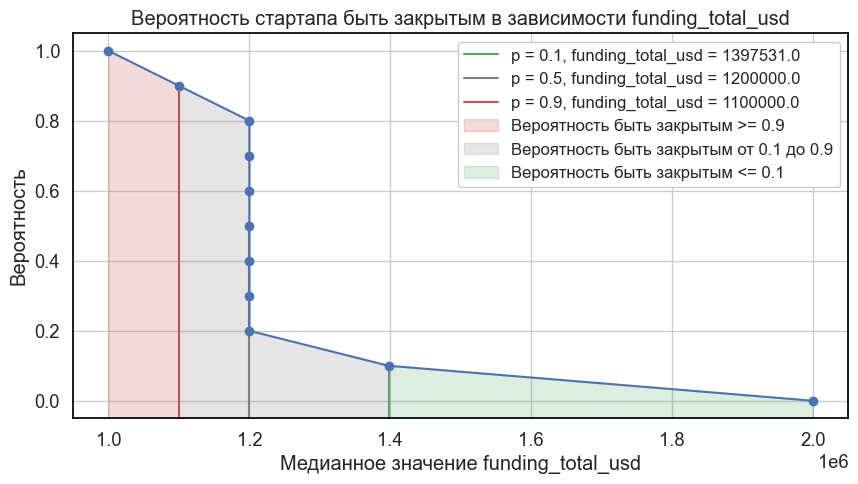

In [110]:
closed_proba_describe('funding_total_usd')

Видна четкая граница в 1.2 млн USD

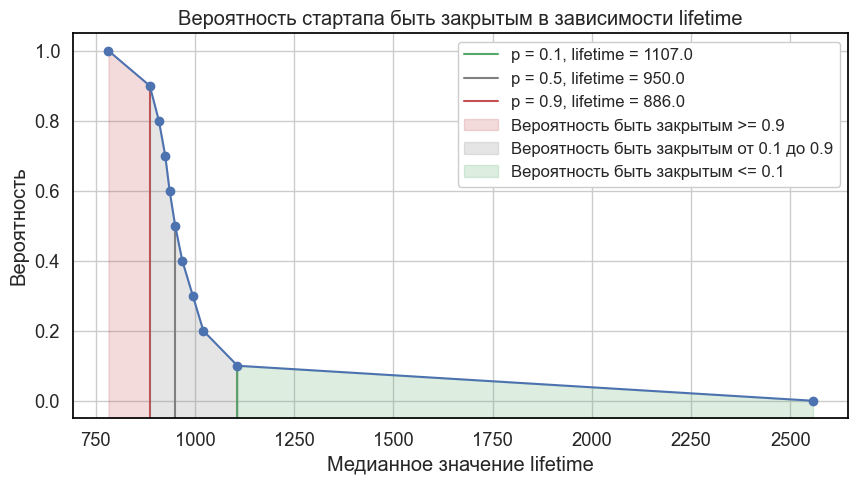

In [111]:
closed_proba_describe('lifetime')

Виден гистерезис в 950 дней

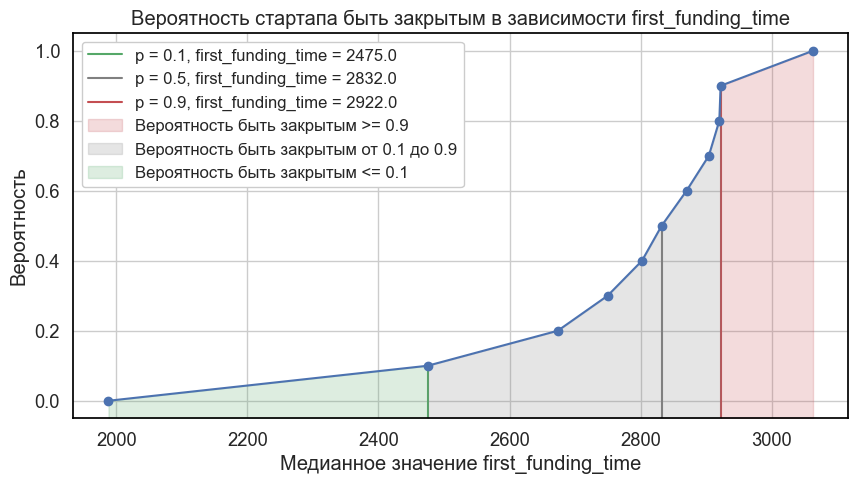

In [112]:
closed_proba_describe('first_funding_time')

Очевидно, что молодые стартапы вероятнее работают. Вероятнее закрыт если первые инвестиции были более 2900 дней, открыт - менее 2000 дней

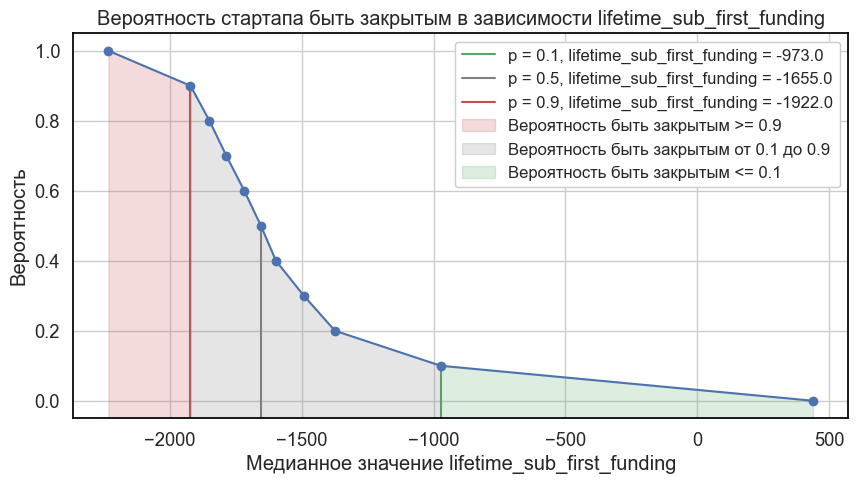

In [113]:
closed_proba_describe('lifetime_sub_first_funding')

Так же очевидно, что стартапы с отрицательной разницей времени жизни и времени с первого финансирования вероятнее закрыты. Хотя есть работающие стартапы с отрицательным показателем - либо некорректная запись в базе, либо искусственные данные

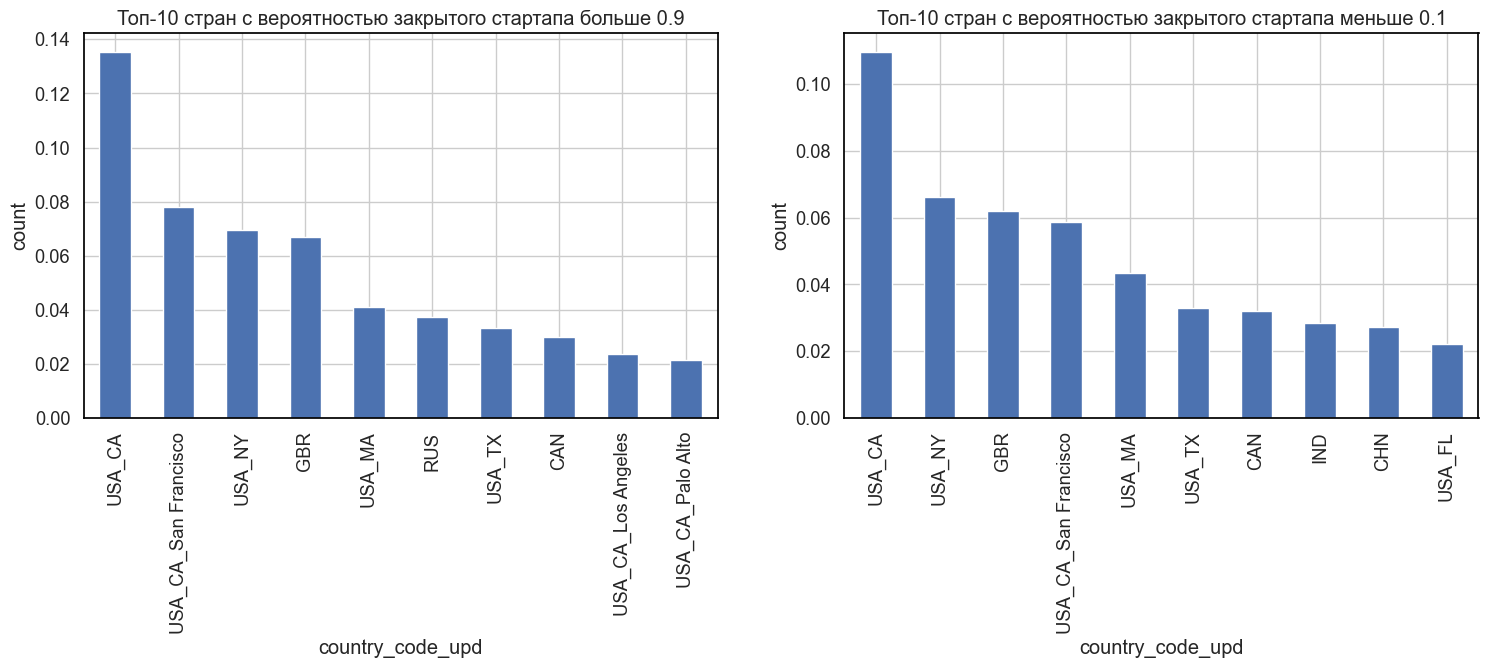

In [114]:
fig, ax = plt.subplots(1, 2 ,figsize=(18,5))
(data_train.query('closed_proba>0.9')['country_code_upd']
 .value_counts(normalize=True)
 .head(10)
 .plot(kind='bar',
       title='Топ-10 стран с вероятностью закрытого стартапа больше 0.9',
       ylabel='count',
       ax=ax[0])
)

(data_train.query('closed_proba<0.1')['country_code_upd']
 .value_counts(normalize=True)
 .head(10)
 .plot(kind='bar',
       title='Топ-10 стран с вероятностью закрытого стартапа меньше 0.1',
       ylabel='count',
       ax=ax[1])
);

- Стартапы в Калифорнии чаще закрываются, чем в других местах. Аналогично и в Нью-Йорке, Англии и т.д. И работают так же чаще всего там
- В России не стоит открывать стартап, там закрываются чаще, а работают намного реже
- Стоит присмотреться к Индии, Китаю и Флориде - там работают чаще, чем закрываются

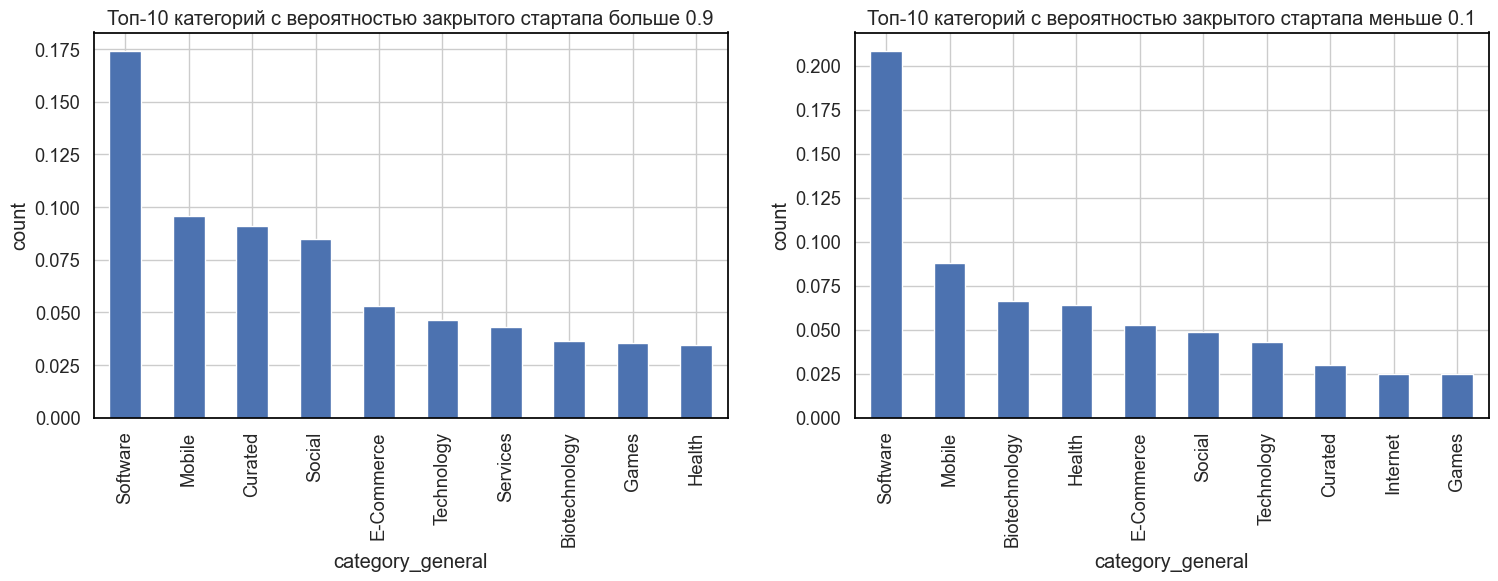

In [115]:
fig, ax = plt.subplots(1, 2 ,figsize=(18,5))
(data_train.query('closed_proba<0.1')['category_general']
 .value_counts(normalize=True)
 .head(10)
 .plot(kind='bar',
       title='Топ-10 категорий с вероятностью закрытого стартапа меньше 0.1',
       ylabel='count',
       ax=ax[1])
)

(data_train.query('closed_proba>0.9')['category_general']
 .value_counts(normalize=True)
 .head(10)
 .plot(kind='bar',
       title='Топ-10 категорий с вероятностью закрытого стартапа больше 0.9',
       ylabel='count',
       ax=ax[0])
);

- Похожая ситуация и в областях стартапов - Софт, мобильный софт и т.д.
- В софт можно заходить, тут стартапы работают чаще, чем в других областях
- Аналогично - биотех, здоровье, тут вероятнее выжить
- В Social лезть не стоит, вероятнее закрыться

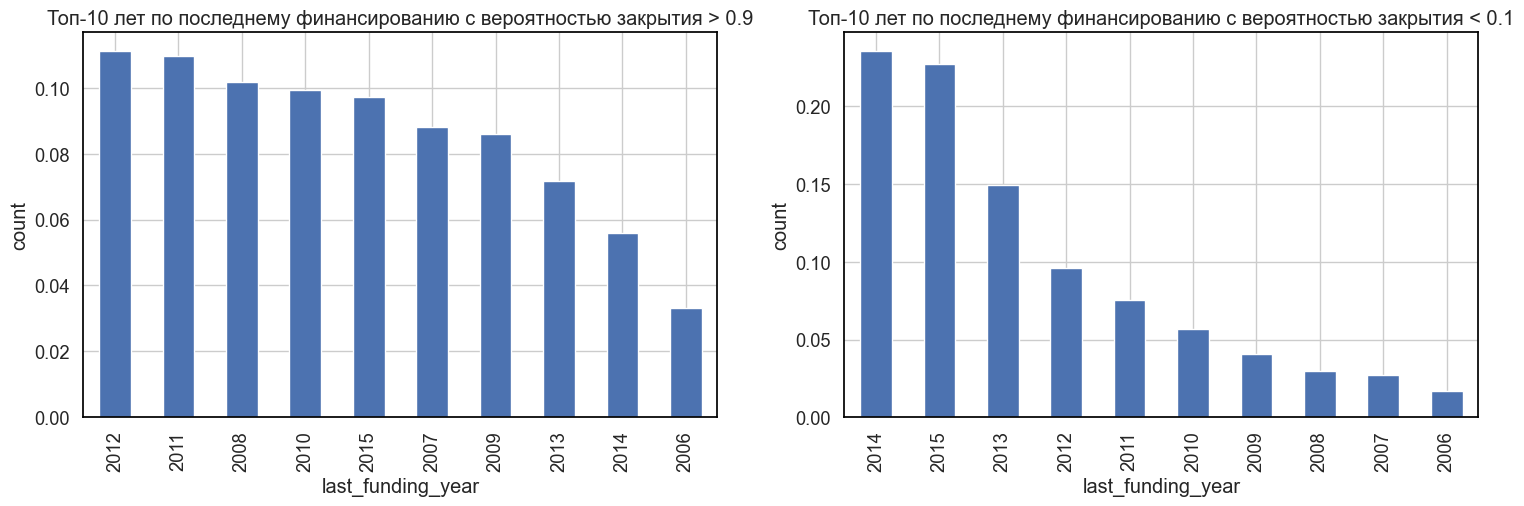

In [116]:
fig, ax = plt.subplots(1, 2 ,figsize=(18,5))
(data_train.query('closed_proba>0.9')['last_funding_year']
 .value_counts(normalize=True)
 .head(10)
 .plot(kind='bar',
       title='Топ-10 лет по последнему финансированию с вероятностью закрытия > 0.9',
       ylabel='count',
       ax=ax[0])
)

(data_train.query('closed_proba<0.1')['last_funding_year']
 .value_counts(normalize=True)
 .head(10)
 .plot(kind='bar',
       title='Топ-10 лет по последнему финансированию с вероятностью закрытия < 0.1',
       ylabel='count',
       ax=ax[1])
);

- Стартапы веротянее закрывались в 2011-12 годах
- А вот в 2014-15 с большей вероятностью работают относительно других годов, особенно 2014

### Вывод

В уточнение к предыдущей сегментации:
- Закрытый стартап
    - Привлек инвестиций меньше 1.2 млн USD
    - Работал меньше 1 тыс дней
    - Вероятнее работает в Калифорнии
    - Скорее всего из области софта
    - Последнее финансирование получил в 2012 году


- Открытый стартап
    - Привлек инвестиций больше 2 млн USD
    - Работал больше 2.5 тыс дней
    - Вероятнее работает в Калифорнии. Стоит присмотреться к Индии, Китаю или Флориде
    - Скорее всего из области софта. Стоит присмотреться к секторам биотеха, здоровья
    - Последнее финансирование получил в 2014-15 году

## Общий вывод

В результате работы на проектом была построена модель предсказания статуса деятельности стартапа. Лучшей моделью из LogisticRegresson, LightGBM и CatBoost оказалась LightGBM. Поиск проводился с помощью GridSearch в две стадии. Были сконструированы дополнительные признаки для улучшения показателей модели. Основная оценка проводилась с помощью F1 метрики. Были составлены портреты закрывшихся и работающих стартапов. В конце даны рекомендации для молодых стартапов / инвесторов.

- **Исходные данные**
    - **Тренировочные данные - `data_train`**
        - 52516 записей
        - пропуски
            - `name`
            - `category_list`
            - `funding_total_usd`
            - `country_code`
            - `state_code`
            - `region`
            - `city`
            - `closed_at`
    - **Тестовые данные - `data_test`**
        - 13125 записей
        - пропуски
            - `category_list`
            - `funding_total_usd`
            - `country_code`
            - `state_code`
            - `region`
            - `city`


- **Предобработка данных**
    - `name` - заполнили 1 пропуск `NoNameStartup`
    - `closed_at` - 45000 пропусков заменили на дату выгрузки данных - `2018-01-01`
    - `lifetime` - добавили признак как в тестовой выбокре равный разнице `closed_at` и `founded_at`
    - `category_list` - разделили по `|` на пять категорий и создали для них соответствующие признаки `category_i`
    - Остальные пропуски заполняем в пайплайне


- **Исследовательский анализ**
    - По резльтатам анализа данных и моделирования вероятности закрытия стартапа можно составить следующие портреты стартапов
    - **Медианный портрет закрывшегося стартапа**
        - Медианный объем инвестиций - менее 1.2 млн USD
        - Медианное время жизни -  менее 1 тыс дней
        - 1 раунд инвестиций
        - Находится в США - Калифорния - Сан-Франциско
        - Вероятнее всего из областей `Software` -> `iPhone`, `Television`, `Reviews`
        - Последнее финансирование получил в 2012 году
        - Медианная разница в днях между последним финансированем и временем жизни - -1231                                            

    - **Медианный портрет работающего стартапа**
        - Медианный объем инвестиций - более 2.0 млн USD
        - Медианное время жизни - более 2.5 тыс дней
        - Больше 1 раунда инвестиций
        - Находится в США - Калифорния - Сан-Франциско
        - Вероятнее всего из областей `Software` -> `IT`, `FinTech`, `Data`
        - Последнее финансирование получил в 2014-15 году
        - Медианная разница в днях между последним финансированем и временем жизни - 706
                
    - **Общие выводы**
        - Сильный дисбаланс между классами - 9 к 1 в пользу работающих
        - `funding_total_usd`
            - Добавили признак `funding_total_usd_log` так как распределение логнормальное
        - `lifetime`
            - Добавили признак `lifetime_log` так как распределение логнормальное
        - `country_code_upd`
            - Заменили все 4 географических признака на `country_code_upd`, где разбили США на штаты, и Калифорнию на штат и пять крупынх городов по количеству стартапов
        - `category_list`
            - Добавили признак `category_general` из топ-100 категорий
        - `funding_time`
            - Добавили новые признаки `first_funding_time`, `last_funding_time`, `between_funding_time`, `last_funding_year`
            - Добавили признак `lifetime_sub_last_funding - разница времени жизни и времени с последней даты финансирования стартапа, возможно именно в ней раскрываются синтетические данные, а возможно некорректная информация в базе по закрытым стартапам

- **Поиск лучшей модели**


Был проведен корреляционный и VIF анализ для оценки возможности использования признаков. С помощью первичного поиска GridSearchCV из трех моделей - LogisticRegression, LightGBM и CatBoost определили лучшего кандидата на дальнейший подбор гиперпараметров - LightGBM. У него были близкие резльутаты с CatBoost - около 0.88, но более быстрое время обучения. LogisticRegression показал резльутат около 0.8. Далее полным перебором гиперпараметров была выбрана следующая модель и после откалибрована:
- **LightGBMClassifier**
    - `encoder` - `OrdinalEncoder`
    - `colsample_bytree` - 0.5
    - `learning_rate` - 0.2
    - `max_depth` - 6
    - `n_estimators` - 200
    - `reg_lambda` - 10
    - `sample_pos_weight` - 100


- **Метрики модели после калибровки**
    - на валидационной выборке
        - F1 - 0.880
        - Precision - 0.937
        - Recall - 0.829
    - на тренировочной выборке
        - F1 - 0.889
        - Precision - 0.978
        - Recall - 0.882


**Входные признаки по влиняию**
- (Сильно) - время жизни
- (Сильно) - (время жизни - кол-во дней с последнего или первого финансирования)
- (Среднее) - время с последнего финансирования до 2018 года
- (Среднее) - финасирование млн USD
- (Среднее) - географичесикй признак
- (Слабо) - категорийные призанки стартапа
- (Слабо) - раунды финансирования


**На соревнование была отправлена модель**
- LightGBMClassifier
    - `encoder` - `OrdinalEncoder`
    - `colsample_bytree` - 0.5
    - `learning_rate` - 0.1
    - `max_depth` - 7
    - `n_estimators` - 200
    - `reg_lambda` - 1
    - `sample_pos_weight` - 100

**Рекомендации заказчику, новым стартапам или инвесторам**

Для поиска или открытия успешного стартапа или улучшения текущей ситуации -
- Желательно перешагнуть порог в 1.2 млн USD, а лучше за 2 млн USD
- Пройти более 1 раунда инвестиций, но не переусердствовать, в районе 4-6 раунда должен быть выход на окупаемость, поглощение крупным игроком или другой поток денежных средств, иначе - с продуктом есть какие-то проблемы
- Удачной локацией будет Индия, Китай, США - Бостон или Флорида, видимо связано с арендой и конкурентностью, условиями со стороны государства
- Желательно заходить в область Software, Biotech или Health, возможно что-то на стыке, там доля работающих стартапов выше, чем закрытых
- С 2010 года популярнее всего по открытым стартапам область IT в платежах и маркетинге, возможно перенасыщение, туда заодить с осторожностью